# 0. Imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

## 0.1. Helper Functions

In [2]:
def plot_distribuicao_por_grupos(df_contratado, df_adimplente, df_inadimplente, col, titulo_legenda=None):
    """
    Plota a distribuição de uma variável categórica ao longo do tempo para três grupos.
    Linhas são interrompidas quando os valores são zero e todos os gráficos usam a mesma escala.
    """
    
    # Criar as tabelas para cada grupo
    tabela_contratado = pd.crosstab(df_contratado['ano_mes'], df_contratado[col], normalize='index')
    tabela_adimplente = pd.crosstab(df_adimplente['ano_mes'], df_adimplente[col], normalize='index')
    tabela_inadimplente = pd.crosstab(df_inadimplente['ano_mes'], df_inadimplente[col], normalize='index')
    
    # Substituir valores 0 por NaN para criar descontinuidades nas linhas
    tabela_contratado = tabela_contratado.replace(0, np.nan)
    tabela_adimplente = tabela_adimplente.replace(0, np.nan)
    tabela_inadimplente = tabela_inadimplente.replace(0, np.nan)
    
    # Encontrar o valor máximo entre todas as tabelas para definir a mesma escala
    max_valor = max(
        tabela_contratado.max().max() if not tabela_contratado.empty else 0,
        tabela_adimplente.max().max() if not tabela_adimplente.empty else 0,
        tabela_inadimplente.max().max() if not tabela_inadimplente.empty else 0
    )
    
    # Adicionar uma pequena margem no topo (10% a mais)
    ylim_max = min(max_valor * 1.1, 1.0)  # Não ultrapassar 100%
    
    # Criar figura com 3 subplots lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Lista com as tabelas e títulos
    tabelas = [
        (tabela_contratado, 'Contratados Total'),
        (tabela_adimplente, 'Adimplentes'),
        (tabela_inadimplente, 'Inadimplentes')
    ]
    
    # Título geral da figura
    fig.suptitle(f'Distribuição de {col} ao longo do tempo', 
                 fontsize=16)
    
    # Plotar cada gráfico
    for ax, (tabela, titulo) in zip(axes, tabelas):
        tabela.plot(ax=ax, figsize=(18,5), legend=False)


        # Pintar fundo dos diferentes períodos         
        ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)         # Janela de Modelagem
        ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)          # Janela de Observação
        ax.axvspan('2024-05-01', tabela.index.max(), color='lightpink', alpha=0.3)    # Em Produção
        
        ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)              # Limbo
        ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)              # Marcador
        ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)              # Efeito Modelo Teste
        ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)              # Marcador
        
        ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)             # Efeito Modelo Produção
        ax.axvspan('2025-01-01', tabela.index.max(), color='lightgray', alpha=0.4)    # Não tem target 1
        
        ax.set_title(titulo)
        ax.set_xlabel('Ano-Mês')
        ax.set_ylabel('Proporção %')
        
        # Definir a mesma escala para todos os gráficos
        ax.set_ylim(0, ylim_max)
        
        # Formatar y-axis como porcentagem
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        
        # Rotacionar labels do eixo x para melhor legibilidade
        ax.tick_params(axis='x', rotation=45)
    
    # Criar uma única legenda para todos os gráficos
    lines = axes[0].get_lines()
    labels = [line.get_label() for line in lines]
    
    # Definir título da legenda
    if titulo_legenda is None:
        titulo_legenda = f'Valores de {col}'
    
    # Posicionar a legenda fora dos gráficos
    fig.legend(lines, labels, 
               loc='center', 
               bbox_to_anchor=(0.5, -0.05),
               ncol=len(labels),
               title=titulo_legenda,
               columnspacing=1.5)
    
    # Ajustar espaçamento para não cortar a legenda
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    plt.show()
    
    return fig, axes

In [3]:
def plot_estatisticas_por_tipo(df, col_numerica, titulo=None):
    """
    Plota média, mediana e coeficiente de variação de uma variável numérica 
    ao longo do tempo para cada tipo.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame com as colunas 'ano_mes', 'tipo' e a coluna numérica
    col_numerica : str
        Nome da coluna numérica a ser analisada
    titulo : str, optional
        Título personalizado para o gráfico
    """
    
    # Calcular estatísticas por ano_mes e tipo
    df_stats = df.groupby(['ano_mes', 'tipo'])[col_numerica].agg([
        ('media', 'mean'),
        ('mediana', 'median'),
        ('std', 'std')
    ]).reset_index()
    
    # Calcular coeficiente de variação (CV = std/mean)
    df_stats['cv'] = df_stats['std'] / df_stats['media']
    
    # Ordenar tipos para consistência nas cores
    ordem_tipos = ['adimplente', 'inadimplente', 'nao_contratado']
    cores = {'nao_contratado': '#95A5A6', 
             'adimplente': '#2ECC71', 
             'inadimplente': '#E74C3C'}
    
    # Criar figura com 3 subplots lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Lista com as estatísticas e títulos
    estatisticas = [
        ('media', 'Média'),
        ('mediana', 'Mediana'),
        ('cv', 'Coeficiente de Variação (σ/μ)')
    ]
    
    # Título geral da figura
    titulo_geral = titulo if titulo else f'Estatísticas de {col_numerica} ao longo do tempo'
    fig.suptitle(titulo_geral, fontsize=16)
    
    # Plotar cada gráfico
    for ax, (estatistica, titulo_graf) in zip(axes, estatisticas):
        
        # Plotar linhas para cada tipo
        for tipo in ordem_tipos:
            dados_tipo = df_stats[df_stats['tipo'] == tipo]
            if not dados_tipo.empty:
                ax.plot(dados_tipo['ano_mes'], dados_tipo[estatistica], 
                       'o-', label=tipo, color=cores.get(tipo, '#333333'), markersize=6)
        
        # Pintar fundo dos períodos (mesmos em todos os gráficos)
        ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)  # Janela de Modelagem
        ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)   # Janela de Observação
        ax.axvspan('2024-05-01', '2025-12-01', color='lightpink', alpha=0.3)   # Em Produção
        ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)       # Limbo
        ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)       # Marcador
        ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)       # Efeito Modelo Teste
        ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)       # Marcador
        ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)      # Efeito Modelo Produção
        ax.axvspan('2025-01-01', '2025-12-01', color='lightgray', alpha=0.4)   # Não tem target 1
        
        # Configurações específicas para CV
        if estatistica == 'cv':
            ax.set_ylabel('Coeficiente de Variação', fontsize=12)
            # Adicionar linha de referência para CV=0.2 (alta variabilidade)
            ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, linewidth=1, label='CV=0.2')
        else:
            ax.set_ylabel(f'{titulo_graf} de {col_numerica}', fontsize=12)
        
        ax.set_xlabel('Ano-Mês', fontsize=12)
        ax.set_title(titulo_graf, fontsize=13)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Ajustar para o título geral
    plt.show()
    
    return fig, axes

In [4]:
from scipy.stats import ks_2samp

def calcular_ks(y_target, y_feature):
    """
    Calcula a estatística KS entre duas distribuições
    
    Parameters:
    -----------
    y_target : array-like
        Variável target (0 = adimplente, 1 = inadimplente)
    y_feature : array-like
        Feature do modelo (probabilidade ou pontuação)
    """
    # Separar scores por classe
    scores_adimplentes = y_feature[y_target == 0]
    scores_inadimplentes = y_feature[y_target == 1]
    
    # Calcular KS usando scipy
    ks_statistic, p_value = ks_2samp(scores_inadimplentes, scores_adimplentes)
    
    return ks_statistic, p_value

def calcular_ks_manual(y_target, y_feature):
    """
    Versão manual para entender o cálculo
    """
    # Criar DataFrame
    df = pd.DataFrame({'score': y_feature, 'target': y_target})
    df = df.sort_values('score')
    
    # Calcular distribuições acumuladas
    total_adimplentes = (df['target'] == 0).sum()
    total_inadimplentes = (df['target'] == 1).sum()
    
    df['cum_adimplentes'] = (df['target'] == 0).cumsum() / total_adimplentes
    df['cum_inadimplentes'] = (df['target'] == 1).cumsum() / total_inadimplentes
    df['diferenca'] = abs(df['cum_inadimplentes'] - df['cum_adimplentes'])
    
    ks = df['diferenca'].max()
    ponto_ks = df.loc[df['diferenca'].idxmax(), 'score']
    
    return ks, ponto_ks
    
def plot_ks(y_target, y_score, titulo="Curva KS"):
    """
    Plota a curva KS mostrando a separação entre as distribuições
    """
    # Preparar dados
    df = pd.DataFrame({'score': y_score, 'target': y_target})
    
    # Calcular KS
    ks, ponto_ks = calcular_ks_manual(y_target, y_score)
    
    # Plotar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Distribuições
    for target, cor, label in [(0, 'green', 'Adimplentes'), (1, 'red', 'Inadimplentes')]:
        sns.kdeplot(data=df[df['target'] == target], x='score', 
                    label=label, color=cor, ax=ax1, fill=True, alpha=0.3)
    
    ax1.axvline(ponto_ks, color='blue', linestyle='--', 
                label=f'Ponto KS: {ponto_ks:.2f}')
    ax1.set_title(f'Distribuições dos Scores\nKS = {ks:.3f}')
    ax1.set_xlabel('Score')
    ax1.set_ylabel('Densidade')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Curva KS (acumuladas)
    df_sorted = df.sort_values('score')
    total_adimplentes = (df['target'] == 0).sum()
    total_inadimplentes = (df['target'] == 1).sum()
    
    cum_adimplentes = (df_sorted['target'] == 0).cumsum() / total_adimplentes
    cum_inadimplentes = (df_sorted['target'] == 1).cumsum() / total_inadimplentes
    scores = df_sorted['score'].values
    
    ax2.plot(scores, cum_adimplentes, 'g-', label='Adimplentes (acumulado)')
    ax2.plot(scores, cum_inadimplentes, 'r-', label='Inadimplentes (acumulado)')
    ax2.plot(scores, abs(cum_inadimplentes - cum_adimplentes), 
             'b--', label='Diferença', alpha=0.7)
    
    # Destacar ponto KS
    idx_ks = np.argmax(abs(cum_inadimplentes - cum_adimplentes))
    ax2.scatter(scores[idx_ks], abs(cum_inadimplentes - cum_adimplentes)[idx_ks],
               color='blue', s=100, zorder=5)
    
    ax2.set_title('Curva KS - Distribuições Acumuladas')
    ax2.set_xlabel('Score')
    ax2.set_ylabel('Proporção Acumulada')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return ks

## 0.2. Loading Data

In [5]:
# Load do arquivo
path_data  = "../data/"
df = pd.read_csv(path_data + '2_envio_case_base_Total_2026.csv', sep=';', encoding='latin-1')

df.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,202301,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,202301,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,202301,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,202301,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,202301,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


## 0.3. Tratamento de variáveis e Novas colunas

In [6]:
# Formatação da coluna 'ano_mes' para datetime
df['ano_mes'] = pd.to_datetime(df['ano_mes'], format='%Y%m')

In [7]:
print('Substituir 1 Registro da coluna vl_bem, de "25a70" para "(25000, 70000]"')

# Substituir valores '25a70' por '(25000, 70000]'
idx = df[df['vl_bem'] == '25a70'].index
df['vl_bem'] = df['vl_bem'].replace('25a70', '(25000, 70000]')

# Verificar se a substituição foi realizada
df[df.index.isin(idx)]

Substituir 1 Registro da coluna vl_bem, de "25a70" para "(25000, 70000]"


,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
399824,362933522,2022-11-01,3_5,Outros,"(25000, 70000]",44,solteiro,0,3045,SE,prof_serv,20,24,2698,1.0,0.0,5,1


In [8]:
# Coluna para janela de tempo (modelagem, observação, limbo, produção verde, produção madura)
# Definir condições
condicoes = [
    (df['ano_mes'] < '2023-03-01'),                                    # Janela de Modelagem
    (df['ano_mes'] >= '2023-03-01') & (df['ano_mes'] < '2024-03-01'),  # Janela de teste OOT
    (df['ano_mes'] >= '2024-03-01') & (df['ano_mes'] < '2024-05-01'),  # Limbo
    (df['ano_mes'] >= '2024-05-01') & (df['ano_mes'] < '2025-01-01'),  # Em Produção target
    (df['ano_mes'] >= '2025-01-01')                                    # Em Produção contrato
]

# Definir valores correspondentes
valores = [
    'modelagem',
    'observacao',
    'limbo',
    'target_completo',
    'target_vazio'
]

# Criar a coluna janela
df['janela'] = np.select(condicoes, valores, default='Outra')

# Imprimir o total de registros em cada grupo
print("---" ) 
print("QUANTIDADE DE REGISTROS POR TIPO")
print("  1. Janela de Modelagem    : ", f"{len(df[df['janela'] == 'modelagem']):,}", f" | {len(df[df['janela'] == 'modelagem'])/(len(df)):.2%} da base")
print("  2. Janela de OOT          : ", f"{len(df[df['janela'] == 'observacao']):,}", f" | {len(df[df['janela'] == 'observacao'])/(len(df)):.2%} da base")
print("  3. Gap do Limbo           : ", f"{len(df[df['janela'] == 'limbo']):,}", f"  | {len(df[df['janela'] == 'limbo'])/(len(df)):.2%} da base")
print("  4. Janela de Produção     : ", f"{len(df[df['janela'] == 'target_completo']):,} + {len(df[df['janela'] == 'target_vazio']):,}", f"| {len(df[df['janela'] == 'target_completo'])/(len(df)):.2%} dos Contratados")
print("     - Target completo      : ", f"{len(df[df['janela'] == 'target_completo']):,} ", f"| {len(df[df['janela'] == 'target_completo'])/(len(df)):.2%} dos Contratados")
print("     - Target vazio         : ", f"{len(df[df['janela'] == 'target_vazio']):,} ", f"| {len(df[df['janela'] == 'target_vazio'])/(len(df)):.2%} dos Contratados")

# Imprimir o período de análise por grupo
print("\n" "---" ) 
print("PERÍODO DE ANÁLISE POR TIPO")
print(f"  1. Janela de modelagem    :  {df[df['janela'] == 'modelagem']['ano_mes'].min()} a {df[df['janela'] == 'modelagem']['ano_mes'].max()}")
print(f"  2. Janela de observação   :  {df[df['janela'] == 'observacao']['ano_mes'].min()} a {df[df['janela'] == 'observacao']['ano_mes'].max()}")
print(f"  3. Gap do Limbo           :  {df[df['janela'] == 'limbo']['ano_mes'].min()} a {df[df['janela'] == 'limbo']['ano_mes'].max()}")
print(f"  4. Janela de produção     :  {df[df['janela'] == 'target_completo']['ano_mes'].min()} a {df[df['janela'] == 'target_completo']['ano_mes'].max()} e {df[df['janela'] == 'target_vazio']['ano_mes'].min()} a {df[df['janela'] == 'target_vazio']['ano_mes'].max()}")
print(f"     - Target completo      :  {df[df['janela'] == 'target_completo']['ano_mes'].min()} a {df[df['janela'] == 'target_completo']['ano_mes'].max()}")
print(f"     - Target vazio         :  {df[df['janela'] == 'target_vazio']['ano_mes'].min()} a {df[df['janela'] == 'target_vazio']['ano_mes'].max()}")

---
QUANTIDADE DE REGISTROS POR TIPO
  1. Janela de Modelagem    :  239,889  | 28.29% da base
  2. Janela de OOT          :  239,940  | 28.29% da base
  3. Gap do Limbo           :  40,237   | 4.74% da base
  4. Janela de Produção     :  159,935 + 168,000 | 18.86% dos Contratados
     - Target completo      :  159,935  | 18.86% dos Contratados
     - Target vazio         :  168,000  | 19.81% dos Contratados

---
PERÍODO DE ANÁLISE POR TIPO
  1. Janela de modelagem    :  2022-03-01 00:00:00 a 2023-02-01 00:00:00
  2. Janela de observação   :  2023-03-01 00:00:00 a 2024-02-01 00:00:00
  3. Gap do Limbo           :  2024-03-01 00:00:00 a 2024-04-01 00:00:00
  4. Janela de produção     :  2024-05-01 00:00:00 a 2024-12-01 00:00:00 e 2025-01-01 00:00:00 a 2025-12-01 00:00:00
     - Target completo      :  2024-05-01 00:00:00 a 2024-12-01 00:00:00
     - Target vazio         :  2025-01-01 00:00:00 a 2025-12-01 00:00:00


In [9]:
# Verificar os valores únicos da coluna 'FPD'  e 'target' para contratados e não contratados
print(df[df['contratado'] == 1]['FPD'].unique())    # OK Faz sentido ter apaenas valores [0. 1.] para contratados
print(df[df['contratado'] == 0]['FPD'].unique())    # OK Faz sentido ter apaenas valores [nan] para não contratados

print(df[df['contratado'] == 1]['target'].unique()) # OK Faz sentido ter apaenas valores [0. 1.] para contratados
print(df[df['contratado'] == 0]['target'].unique()) # OK Faz sentido ter apaenas valores [nan] para não contratados

[0. 1.]
[nan]
[0. 1.]
[nan]


> Aqui pode fazer sentido para o negócio manter target 0 neste período, pois os clientes contrataram e ainda não inadimpliram, 
> ou seja, estão no início do ciclo de crédito e ainda não tiveram tempo suficiente para se tornarem inadimplentes.
> 
> Mas manter target 0 na análise pode distorcer informações ou métricas de performance, pois a informação está incompleta. 


In [10]:
df['vl_bem'] = df['vl_bem'].replace('25a70', '(25000, 70000]')

In [11]:
# Verificar os valores únicos da coluna 'target' para a janela 'target_vazio'
print(df[df['janela'] == 'target_vazio']['target'].unique()) # NOT OK

# Vamos substituir os valores 0 da coluna 'target' para NaN, pois a janela 'target_vazio' representa clientes que não tem target completamente maduro.
idx = df[(df['janela'] == 'target_vazio') & (df['target'] == 0)].index
df.loc[df.index.isin(idx), 'target'] = np.nan
print(df[df['janela'] == 'target_vazio']['target'].unique()) # OK
df[df.index.isin(idx)]
                                                              

[ 0. nan]
[nan]


,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado,janela
680001,922006575,2025-03-01,10,Honda,"(25000, 70000]",34,casado,0,25130,NE,prof_serv,30,48,1141,NaN,0.0,8,1,target_vazio
680002,169501582,2025-02-01,1_2,Fiat,"(25000, 70000]",59,divorciado,1,3013,SE,consignados,50,48,796,NaN,0.0,8,1,target_vazio
680003,287728063,2025-02-01,6_10,Ford,"(25000, 70000]",27,casado,0,17569,SE,assalariados,10,48,1568,NaN,0.0,6,1,target_vazio
680004,158976968,2025-01-01,10,VW,"(25000, 70000]",40,solteiro,0,4956,CO,consignados,20,48,1254,NaN,1.0,7,1,target_vazio
680005,844348769,2025-02-01,1_2,VW,"(25000, 70000]",33,solteiro,0,24711,NE,liberais,40,24,827,NaN,0.0,9,1,target_vazio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847996,600142159,2025-04-01,0,Fiat,"(0, 25000]",28,divorciado,1,25204,SE,autonomos,30,48,498,NaN,0.0,5,1,target_vazio
847997,403548606,2025-04-01,3_5,VW,"(25000, 70000]",31,solteiro,0,15600,SE,prof_serv,20,48,1086,NaN,0.0,7,1,target_vazio
847998,243974759,2025-05-01,1_2,Ford,"(25000, 70000]",51,viuvo,1,4195,CO,autonomos,10,36,1083,NaN,0.0,5,1,target_vazio
847999,323667257,2025-10-01,1_2,Fiat,"(25000, 70000]",33,divorciado,0,26194,SE,autonomos,30,48,599,NaN,0.0,7,1,target_vazio


In [12]:
# Coluna para tipo de cliente (adimplente, inadimplente, não contratado)
# Definir condições
condicoes = [
    (df['contratado'] == 0),                        # Não Contratado (Ponto Cego)
    (df['contratado'] == 1) & (df['target'] == 0),  # Adimplente
    (df['contratado'] == 1) & (df['target'] == 1)   # Inadimplente
]

# Definir valores correspondentes
valores = [
    'nao_contratado',
    'adimplente',
    'inadimplente',
]

# Criar a coluna tipo
df['tipo'] = np.select(condicoes, valores, default='Desconhecido')
df['tipo'].unique()

# Imprimir o total de registros em cada grupo
print("---" ) 
print("QUANTIDADE DE REGISTROS POR TIPO")
total_base = len(df)
total_contratados = len(df[df['tipo'].isin(['adimplente','inadimplente'])])

# Imprimir o total de registros em cada grupo
print("---" ) 
print("QUANTIDADE DE REGISTROS POR TIPO")
print("  1. Não Contratados : ", f"{len(df[df['tipo'] == 'nao_contratado']):,}", f"| {len(df[df['tipo'] == 'nao_contratado'])/total_base:.2%} da base")
print("  2. Contratados     : ", f"{len(df[df['tipo'].isin(['adimplente','inadimplente'])]):,}", f"| {len(df[df['tipo'].isin(['adimplente','inadimplente'])])/total_base:.2%} da base")
print("     - Adimplente    : ", f"{len(df[df['tipo'] == 'adimplente']):,}", f"| {len(df[df['tipo'] == 'adimplente'])/total_contratados:.2%} dos Contratados")
print("     - Inadimplente  : ", f"{len(df[df['tipo'] == 'inadimplente']):,} ", f"| {len(df[df['tipo'] == 'inadimplente'])/total_contratados:.2%} dos Contratados")

# Imprimir o período de análise por grupo
print("\n" "---" ) 
print("PERÍODO DE ANÁLISE POR TIPO")
print(f"  1. Não Contratados :  {df[df['tipo'] == 'nao_contratado']['ano_mes'].min()} a {df[df['tipo'] == 'nao_contratado']['ano_mes'].max()}")
print(f"  2. Contratados     :  {df[df['tipo'].isin(['adimplente','inadimplente'])]['ano_mes'].min()} a {df[df['tipo'].isin(['adimplente','inadimplente'])]['ano_mes'].max()}")
print(f"     - Adimplente    :  {df[df['tipo'] == 'adimplente']['ano_mes'].min()} a {df[df['tipo'] == 'adimplente']['ano_mes'].max()}")
print(f"     - Inadimplente  :  {df[df['tipo'] == 'inadimplente']['ano_mes'].min()} a {df[df['tipo'] == 'inadimplente']['ano_mes'].max()}")


---
QUANTIDADE DE REGISTROS POR TIPO
---
QUANTIDADE DE REGISTROS POR TIPO
  1. Não Contratados :  192,550 | 22.71% da base
  2. Contratados     :  521,679 | 61.52% da base
     - Adimplente    :  453,824 | 86.99% dos Contratados
     - Inadimplente  :  67,855  | 13.01% dos Contratados

---
PERÍODO DE ANÁLISE POR TIPO
  1. Não Contratados :  2022-03-01 00:00:00 a 2025-12-01 00:00:00
  2. Contratados     :  2022-03-01 00:00:00 a 2024-12-01 00:00:00
     - Adimplente    :  2022-03-01 00:00:00 a 2024-12-01 00:00:00
     - Inadimplente  :  2022-03-01 00:00:00 a 2024-12-01 00:00:00


In [13]:
df['tipo'].unique()

<StringArray>
['adimplente', 'inadimplente', 'nao_contratado', 'Desconhecido']
Length: 4, dtype: str

# 1. EDA

EASTER EGG's:
1. Erro de base: vl_bem = 25a70;
2. Erro de base: Tem 347 id's que repetem, sendo que a repetição máxima é de 2 vezes e claramente não se tratam da mesma pessoa e nem do mesmo contrato;
3. score: Os scores de 1 a 4 foram descontinuados, então não devem fazer parte da análise:
   - De monitoramento de perfil;
4. qt_restr: 

## 1.0. Análise por feature

PERÍODO                | DESCRIÇÃO            | Observação         
--                     | --                   | --
['202203' - '202303')  | Janela de modelagem  | 
['202303' - '202403')  | Janela de observação | ['202303']: Marcador, <br>['202309']: Efeito Modelo Teste
['202403' - '202405')  | Limbo                | 
['202405']             | Implantado           | 
['202405' - 202512]    | Em produção          | ['202410', '202501'): Efeito Modelo Produção, <br>['202501', '202512'): Não tem taget = 1, <br>['202503']: Marcador

## 1.0.1. Variáveis Categóricas

FEATURE       | Mudou? | OBSERVAÇÃO
--            | --     | --
score         |        | **
FPD           |        | Em 2025 não tem inadimplentes, mas tem FPD's
Profissao     | não    | 
Regiao        |        | 
idade_veiculo |        | 
vl_bem        |        | 
qt_restr      |        | 
marca         |        | 
estado_civil  |        | 
entrada       |        | 
prazo         |        | 

## 1.0.2. Variáveis Numéricas

FEATURE   | OBSERVAÇÃO
--        | --
idade     | 
pmt       | 
renda     | 


## 0.1. Filtro e seleção

In [14]:
# Separar os dados em contratados e não contratados
df_nao_contratado = df[(df['tipo'] == 'nao_contratado') & 
                       (df['score'] > 4)].copy()  
                       
df_contratado     = df[(df['tipo'].isin(['adimplente','inadimplente'])) & 
                       (df['score'] > 4)].copy() 

# Separar os dados em contratados inadimplentes e adimplentes
df_adimplente     = df[(df['tipo'] == 'adimplente') &
                       (~df['janela'].isin(['target_vazio']))& 
                       (df['score'] > 4)].copy()     
                       
df_inadimplente   = df[(df['tipo'] == 'inadimplente') &
                       (~df['janela'].isin(['target_vazio']))& 
                       (df['score'] > 4)].copy() 

In [15]:
df_nao_contratado['score'].unique()

array([ 5,  7,  6,  8,  9, 10])

In [16]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = cat_cols + ['FPD', 'entrada', 'prazo', 'score']

cat_cols = sorted(cat_cols)
num_cols = sorted(['idade', 'pmt', 'renda'])

print("Colunas categóricas : ", cat_cols)
print("Colunas numéricas   : ", num_cols)

Colunas categóricas :  ['FPD', 'Profissao', 'Regiao', 'ano_mes', 'entrada', 'estado_civil', 'idade_veiculo', 'janela', 'marca', 'prazo', 'qt_restr', 'score', 'tipo', 'vl_bem']
Colunas numéricas   :  ['idade', 'pmt', 'renda']


## 1.1. Análise Descritiva

In [17]:
df_contratado.describe().T

,count,mean,min,25%,50%,75%,max,std
id,469232.0,550369789.173488,100000316.0,325683016.0,550603547.0,775274488.75,999999446.0,259806288.110946
ano_mes,469232,2023-08-05 12:45:03.038156,2022-03-01 00:00:00,2022-11-01 00:00:00,2023-08-01 00:00:00,2024-05-01 00:00:00,2024-12-01 00:00:00,NaN
idade,469232.0,40.432481,18.0,34.0,40.0,47.0,84.0,9.876203
renda,469232.0,14040.763554,3000.0,4742.0,13003.0,23109.0,27576.0,8985.001408
entrada,469232.0,25.465569,0.0,10.0,20.0,40.0,50.0,15.547414
prazo,469232.0,38.891133,12.0,36.0,36.0,48.0,60.0,11.359183
pmt,469232.0,1196.346191,216.0,746.0,1077.0,1475.0,9197.0,668.848127
target,469232.0,0.108187,0.0,0.0,0.0,0.0,1.0,0.310617
FPD,469232.0,0.027453,0.0,0.0,0.0,0.0,1.0,0.163401
score,469232.0,7.078281,5.0,6.0,7.0,8.0,10.0,1.326732


In [18]:
# Quantidade de vezes que cada id aparece
# Ordenar por quantidade de ocorrências
id_counts = df['id'].value_counts()
id_counts_sorted = id_counts.sort_values(ascending=False)

# Mostrar apenas os ids que aparecem mais de 1 vez
id_counts_sorted[id_counts_sorted > 1]

id
683007563    2
300820964    2
624009585    2
516245139    2
621419356    2
            ..
753059689    2
921938891    2
440709480    2
875116961    2
688567809    2
Name: count, Length: 347, dtype: int64

## 1.2. Análise Visual

### 1.2.1. Variáveis Categóricas

- entrada
  - O valor de entrada 0 ter baixa inadimplência é estranho, mas faz sentido que % seja maior do que na base de adimplentes (15% > 10%) E ele está de acordo com a janela de modelagem;
- idade_veiculo
  - Não faz sentido que 

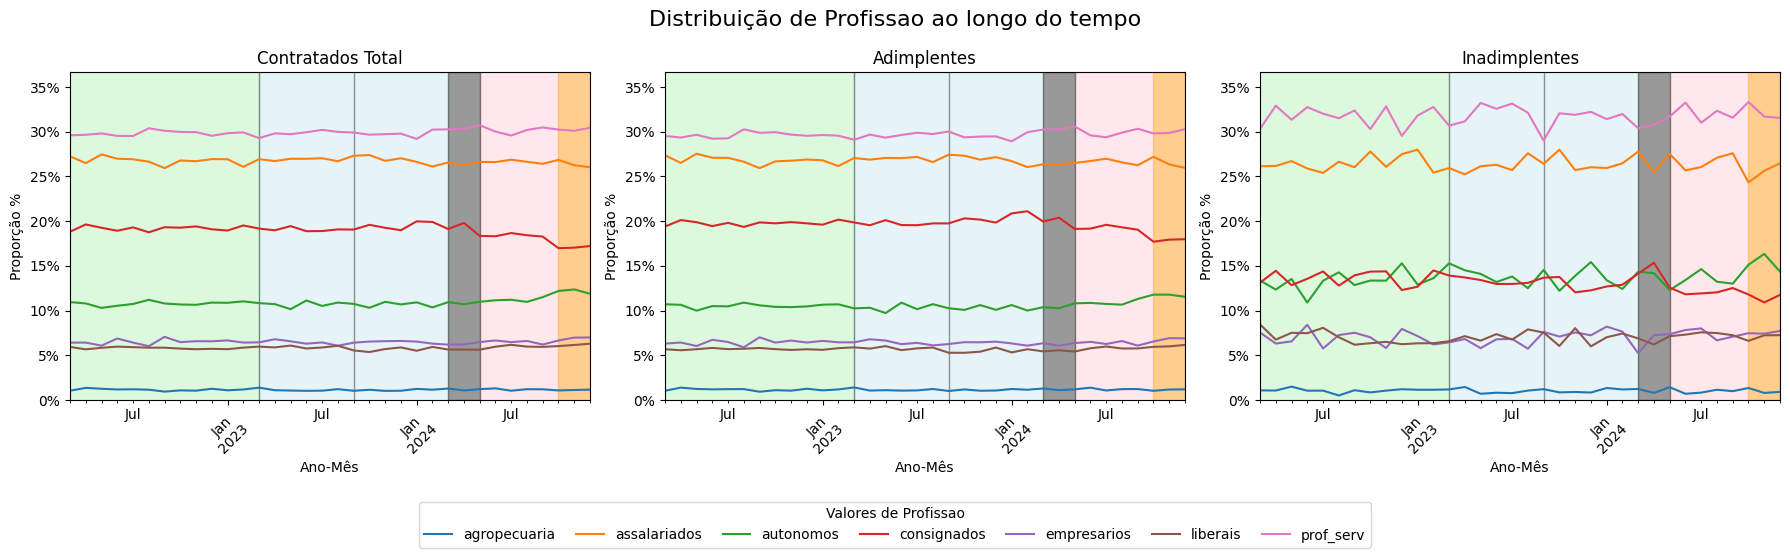

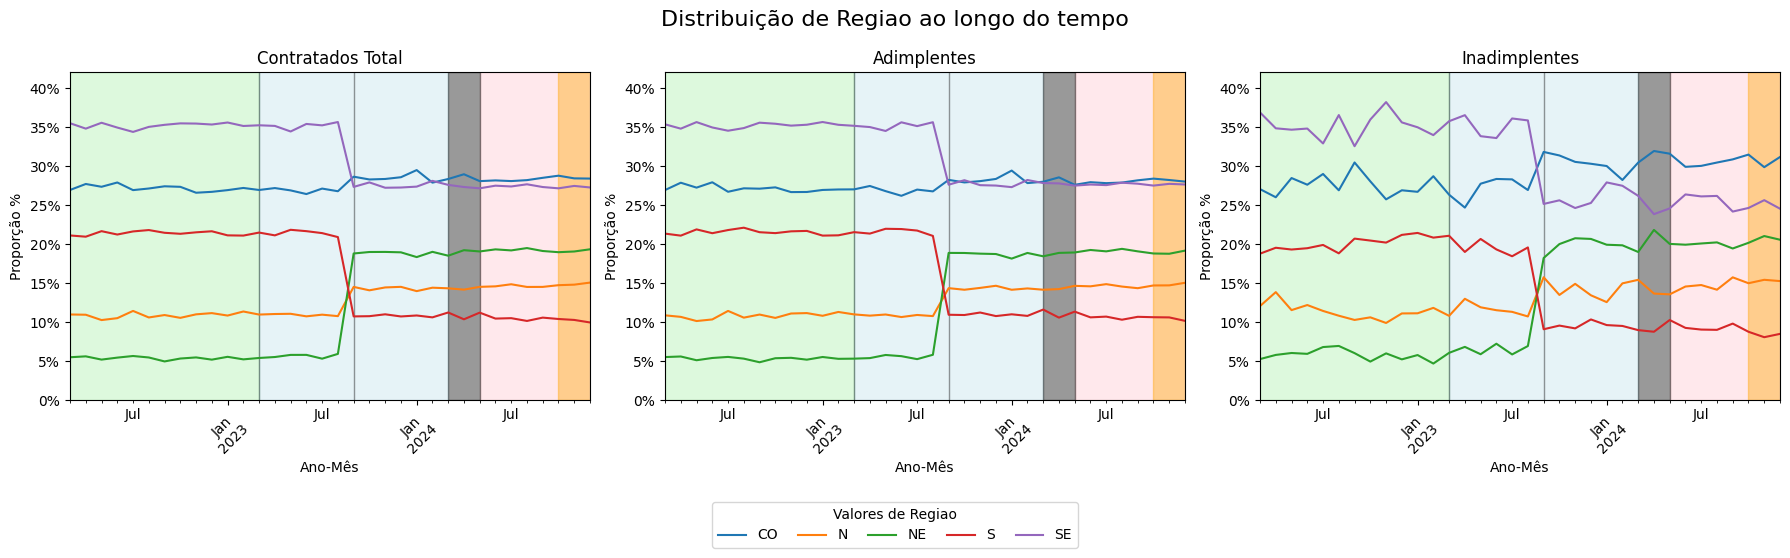

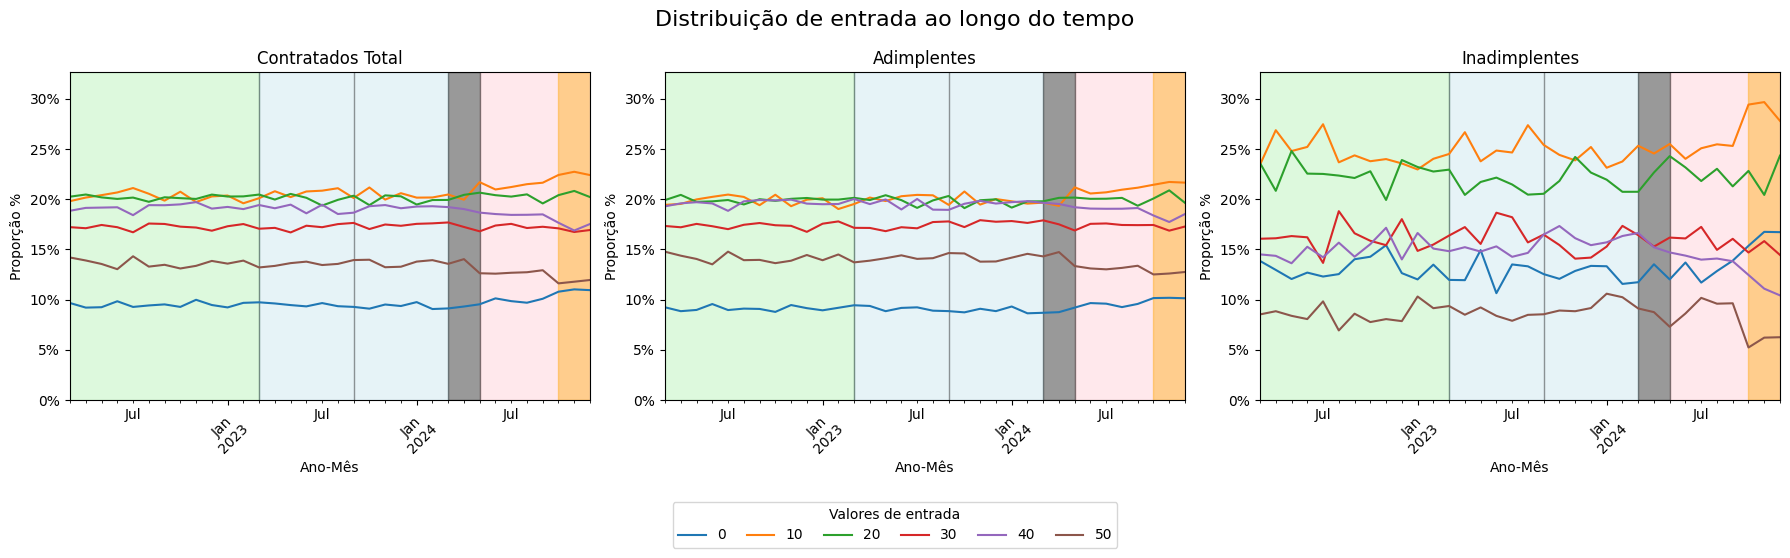

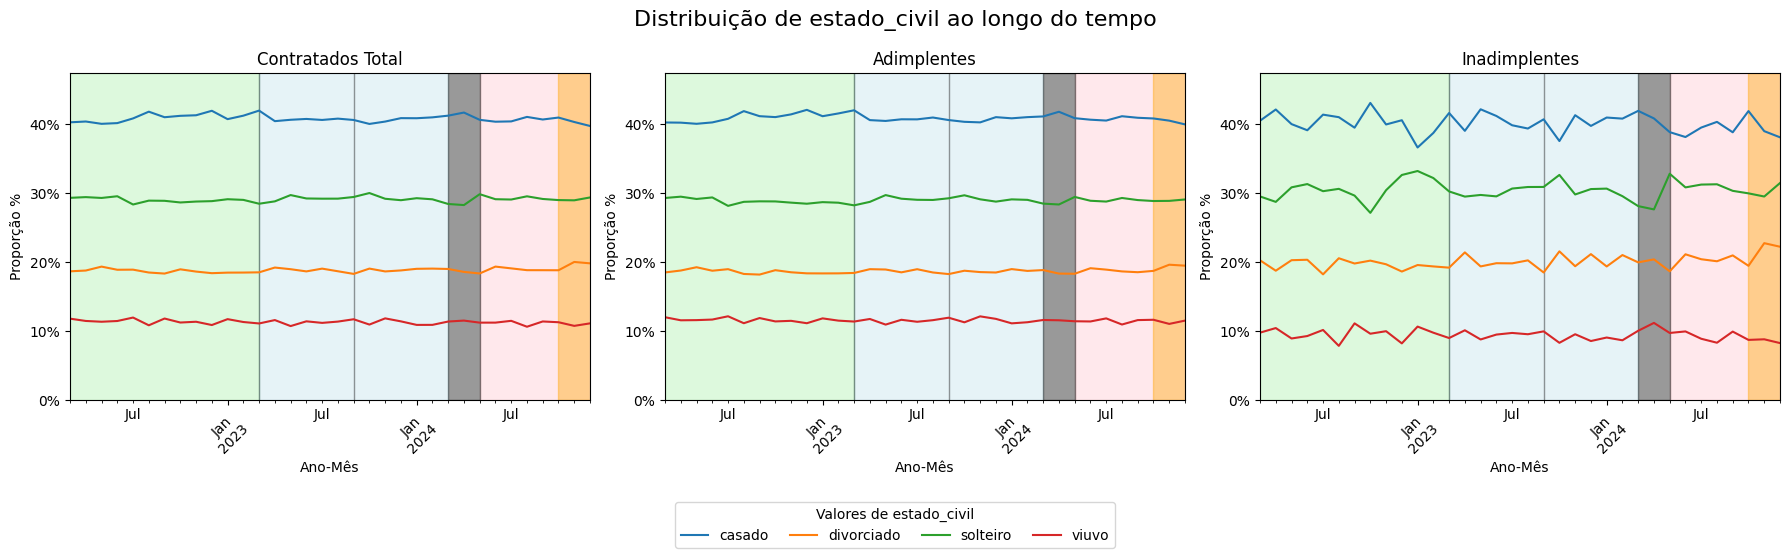

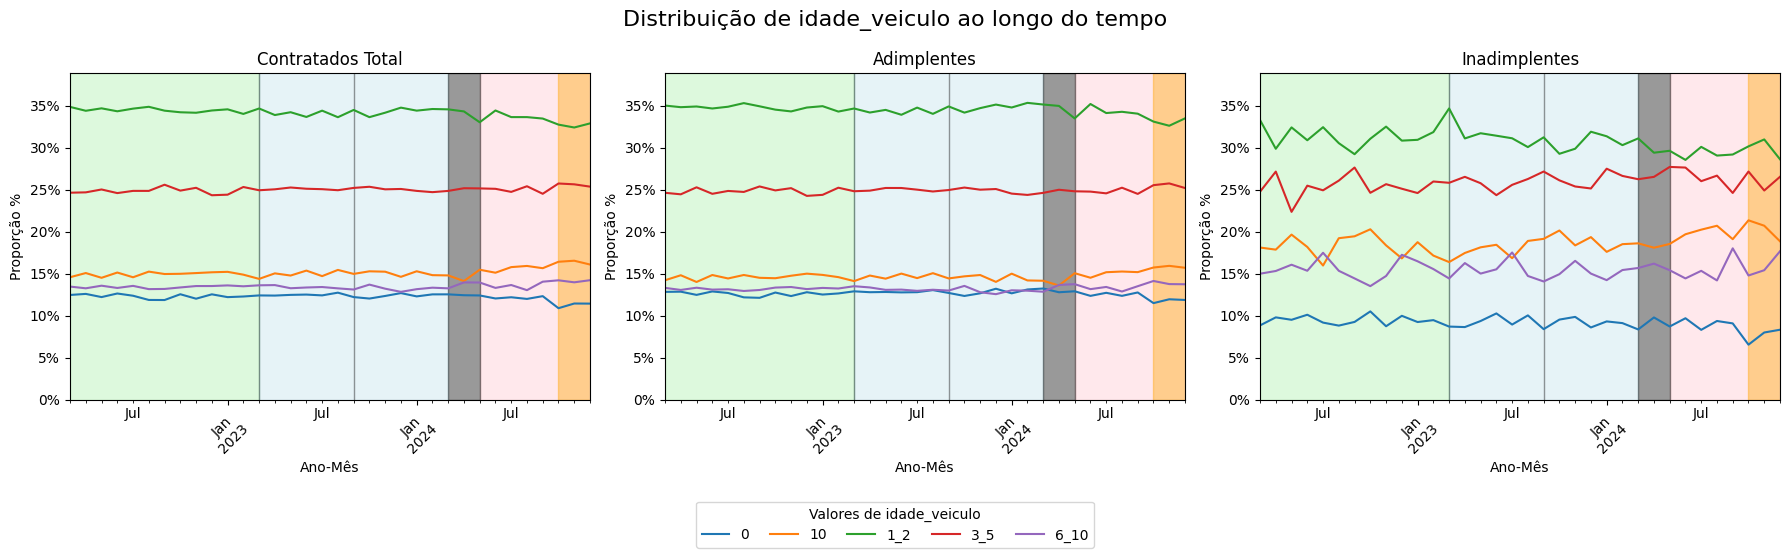

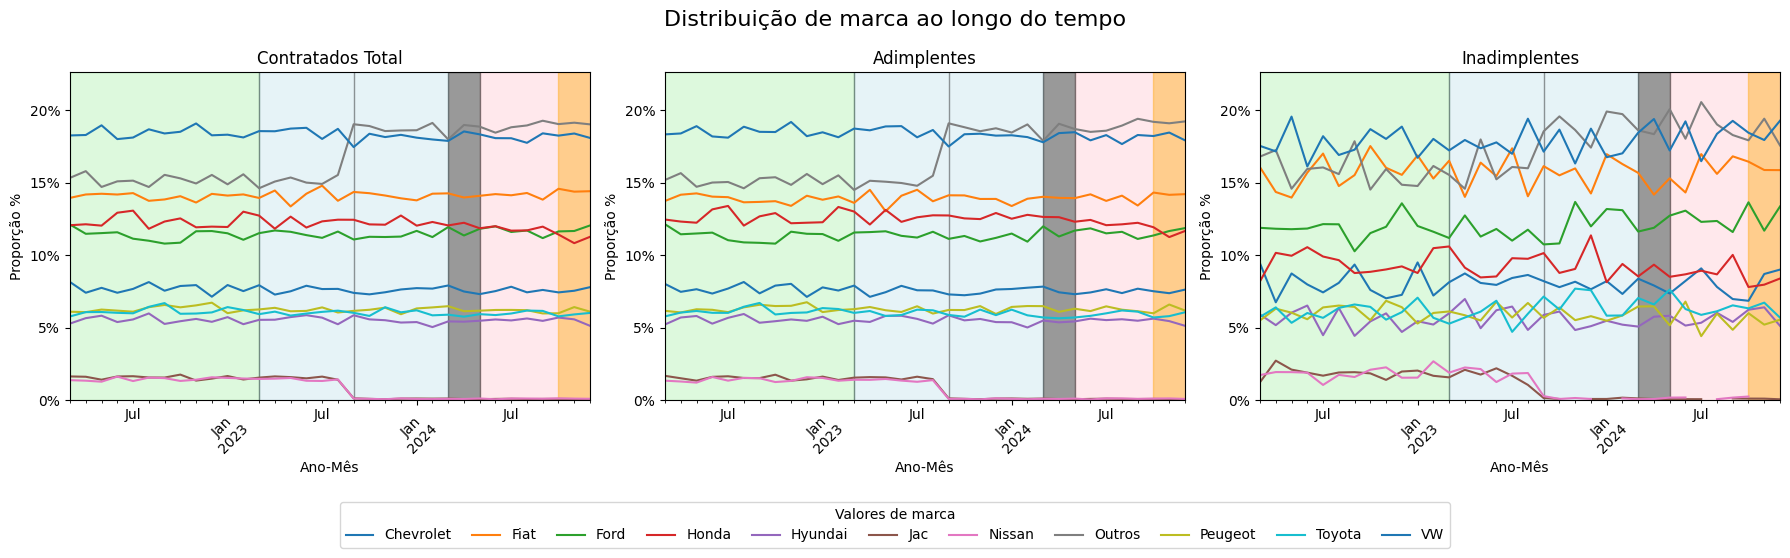

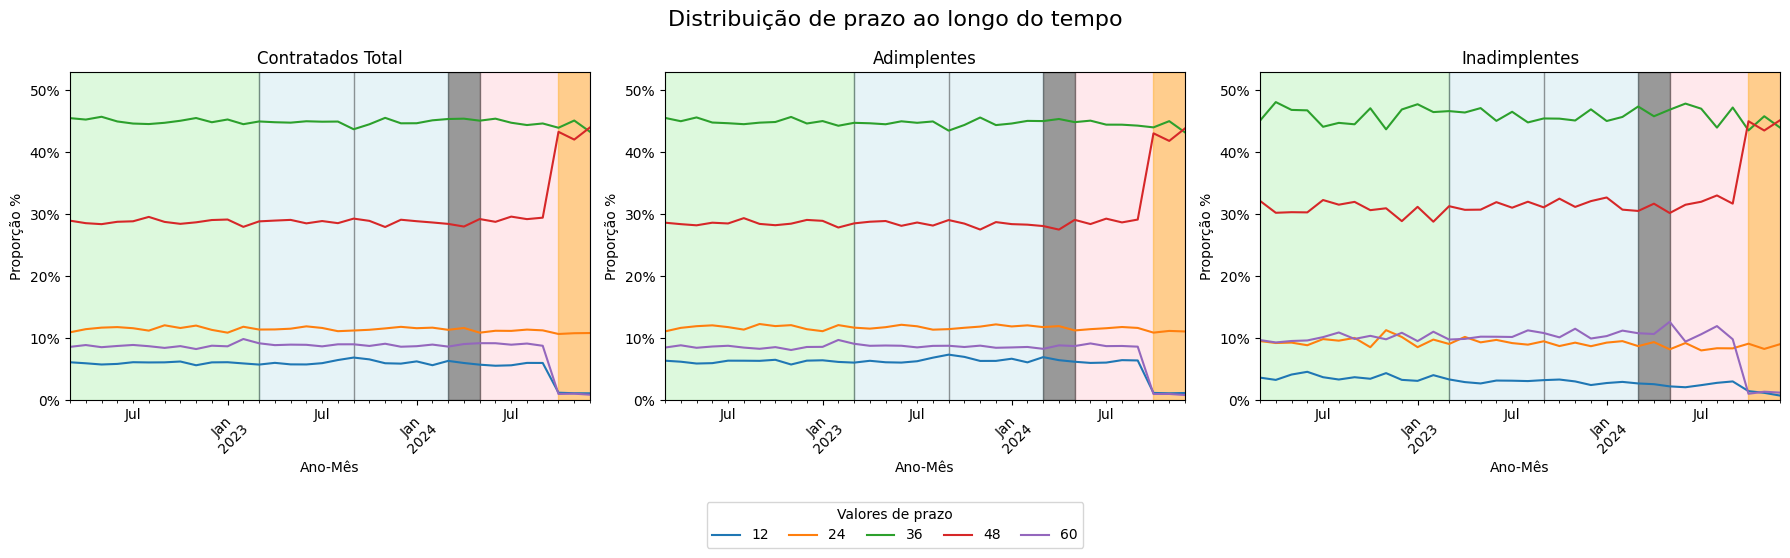

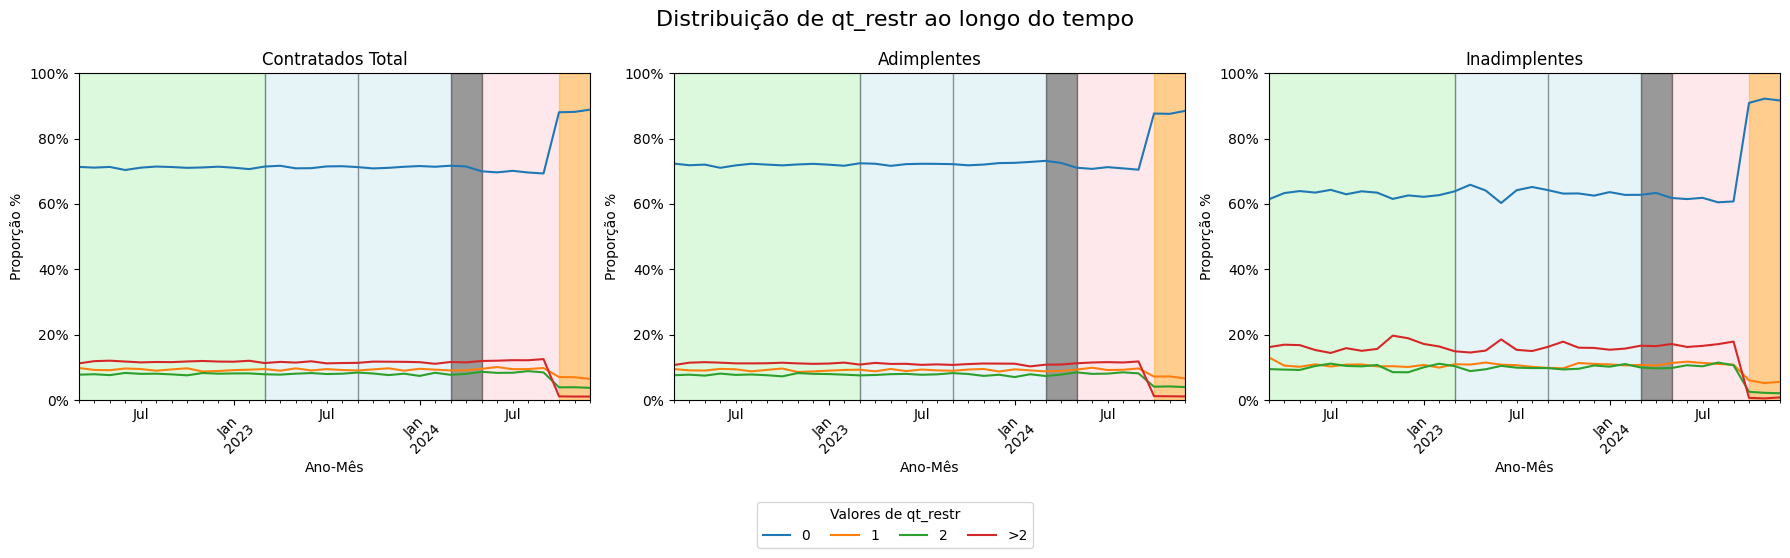

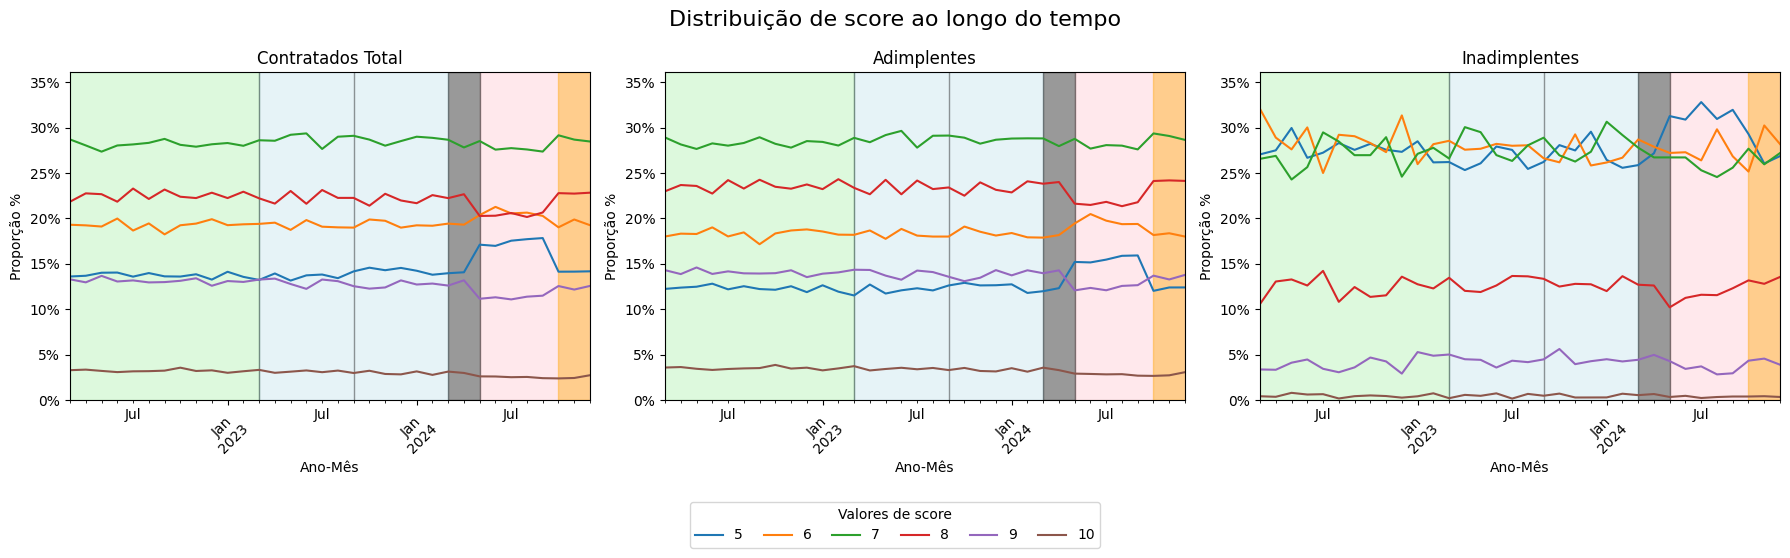

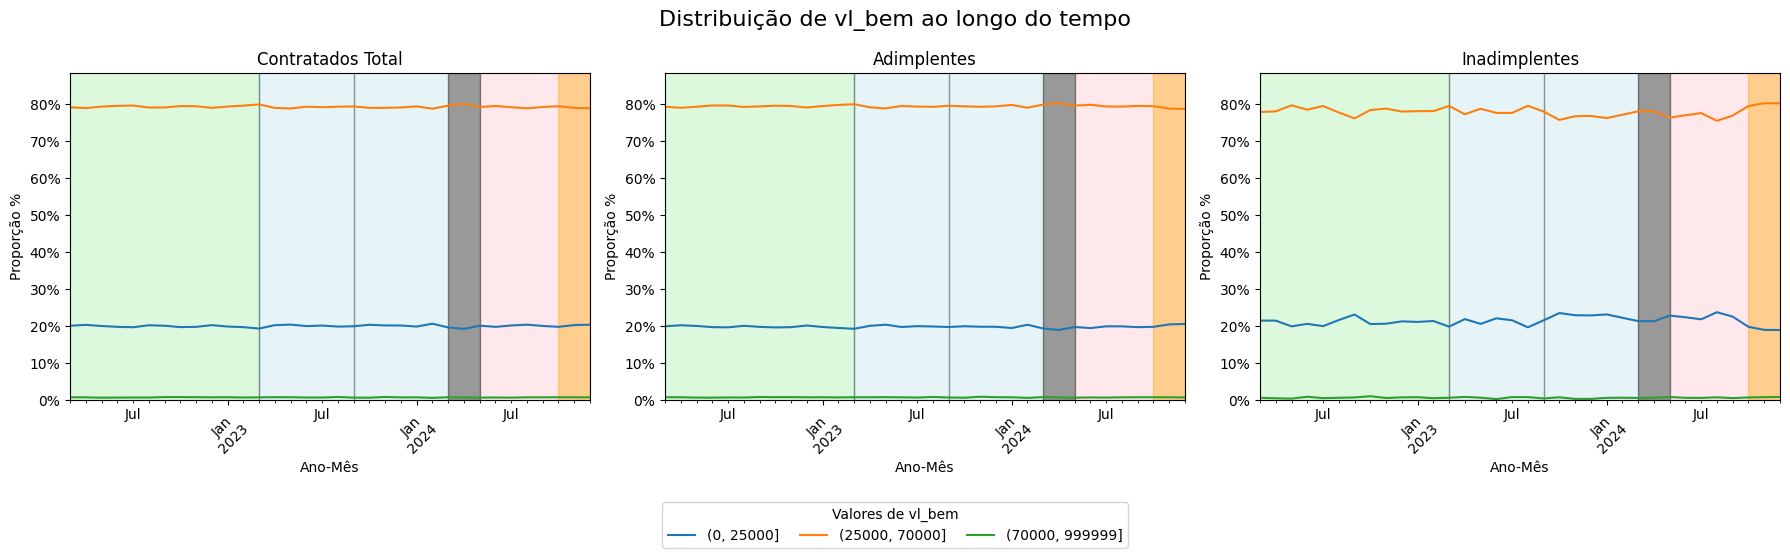

In [19]:
cols = cat_cols

for coluna in cols:
    if coluna in ['ano_mes', 'FPD', 'tipo', 'janela']:
        continue
    plot_distribuicao_por_grupos(df_contratado, df_adimplente, df_inadimplente, col=coluna)

In [20]:
# Para todos os scores
resultado = df[df['contratado'] == 1].groupby(['score'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável score:')
print(resultado)

# Para todos os Profissao
resultado = df[df['contratado'] == 1].groupby(['Profissao'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável Profissao:')
print(resultado)

# Para todos os Regiao
resultado = df[df['contratado'] == 1].groupby(['Regiao'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável Regiao:')
print(resultado)

# Para todas as marcas
resultado = df[df['contratado'] == 1].groupby(['marca'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável marca:')
print(resultado)

# Para todas as entrada
resultado = df[df['contratado'] == 1].groupby(['entrada'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável entrada:')
print(resultado)

# Para todas as estado_civil
resultado = df[df['contratado'] == 1].groupby(['estado_civil'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável estado_civil:')
print(resultado)

# Para todas as idade_veiculo
resultado = df[df['contratado'] == 1].groupby(['idade_veiculo'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável idade_veiculo:')
print(resultado)

# Para todos os qt_restr
resultado = df[df['contratado'] == 1].groupby(['qt_restr'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável qt_restr:')
print(resultado)

# Para todos os vl_bem
resultado = df[df['contratado'] == 1].groupby(['vl_bem'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável vl_bem:')
print(resultado)

# Para todos os prazos
resultado = df[df['contratado'] == 1].groupby(['prazo'])['ano_mes'].agg(['min', 'max'])
print("\n" "---" ) 
print('Datas de início e fim da variável prazo:')
print(resultado)


---
Datas de início e fim da variável score:
             min        max
score                      
1     2022-03-01 2024-04-01
2     2022-03-01 2024-04-01
3     2022-03-01 2024-04-01
4     2022-03-01 2024-04-01
5     2022-03-01 2025-12-01
6     2022-03-01 2025-12-01
7     2022-03-01 2025-12-01
8     2022-03-01 2025-12-01
9     2022-03-01 2025-12-01
10    2022-03-01 2025-12-01

---
Datas de início e fim da variável Profissao:
                    min        max
Profissao                         
agropecuaria 2022-03-01 2025-12-01
assalariados 2022-03-01 2025-12-01
autonomos    2022-03-01 2025-12-01
consignados  2022-03-01 2025-12-01
empresarios  2022-03-01 2025-12-01
liberais     2022-03-01 2025-12-01
prof_serv    2022-03-01 2025-12-01

---
Datas de início e fim da variável Regiao:
              min        max
Regiao                      
CO     2022-03-01 2025-12-01
N      2022-03-01 2025-12-01
NE     2022-03-01 2025-12-01
S      2022-03-01 2025-12-01
SE     2022-03-01 2025-12-01

--

### 1.2.2. Variáveis Numéricas

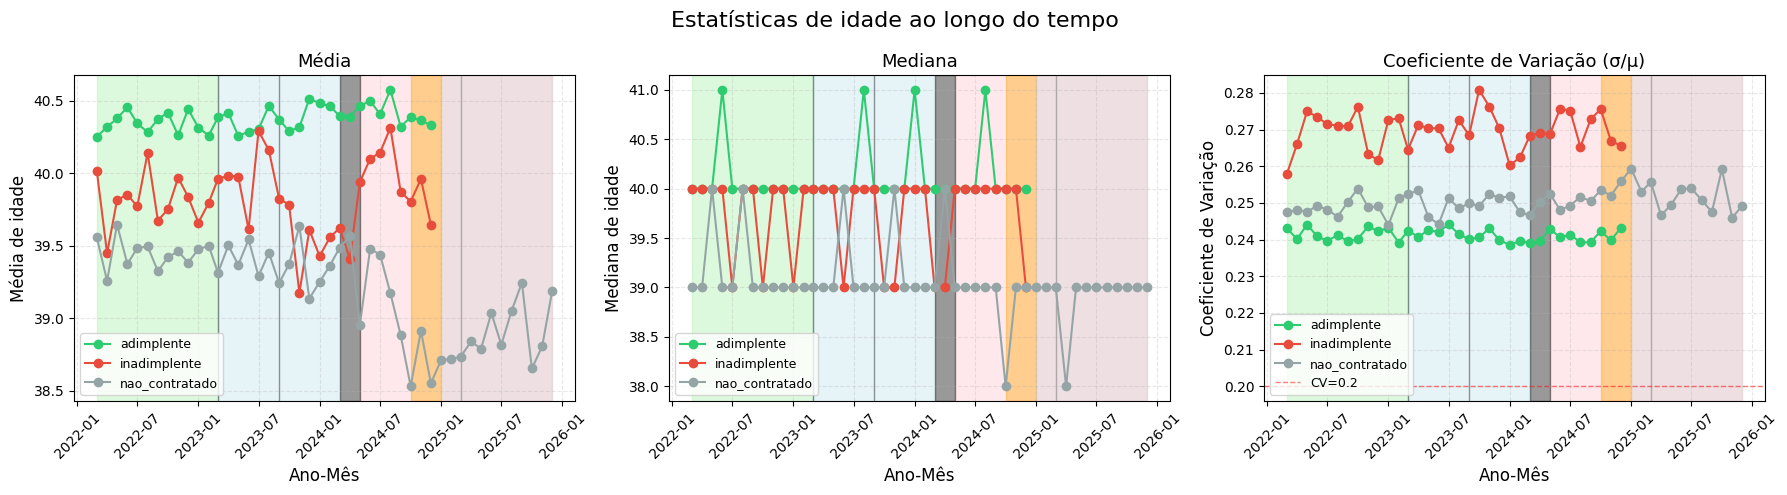

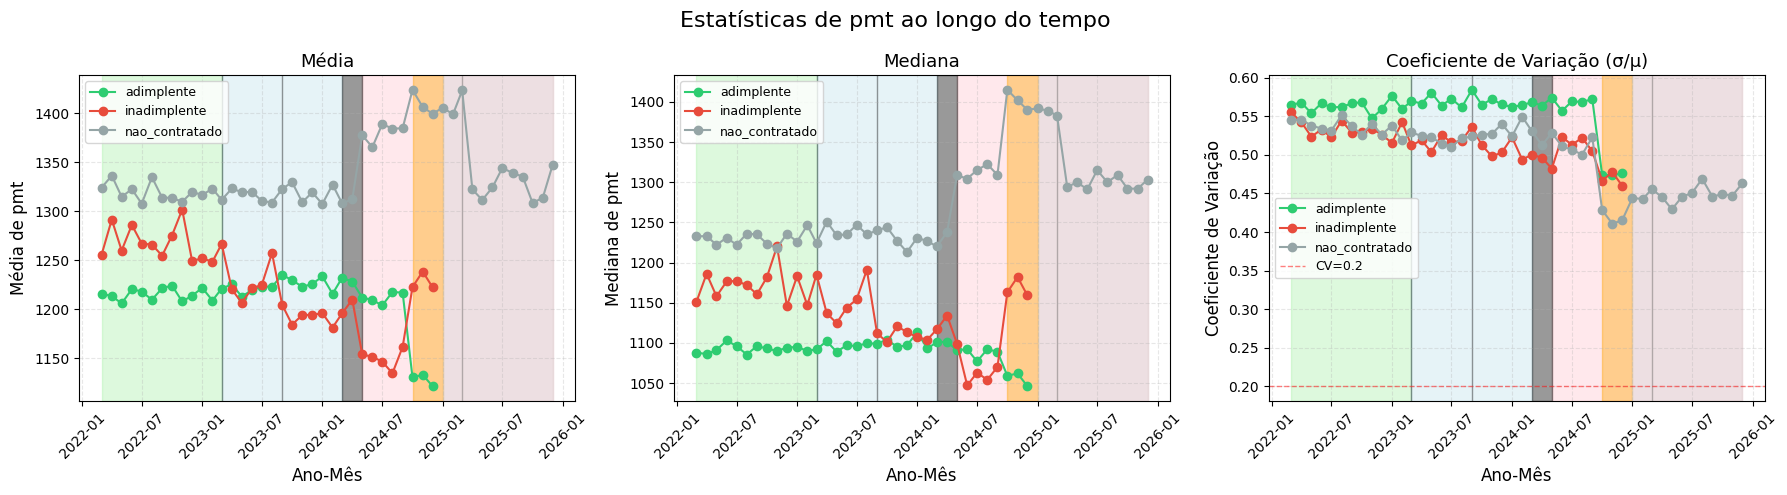

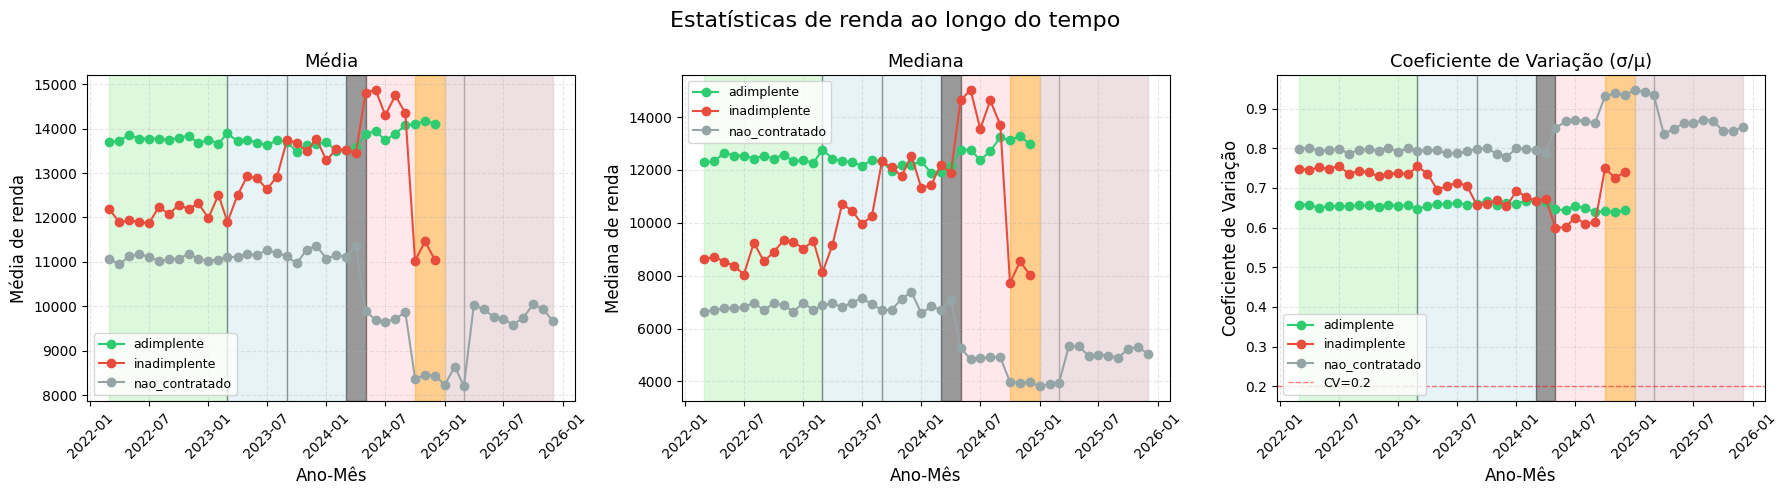

In [23]:
cols = num_cols

for coluna in cols:
    plot_estatisticas_por_tipo(df, coluna)

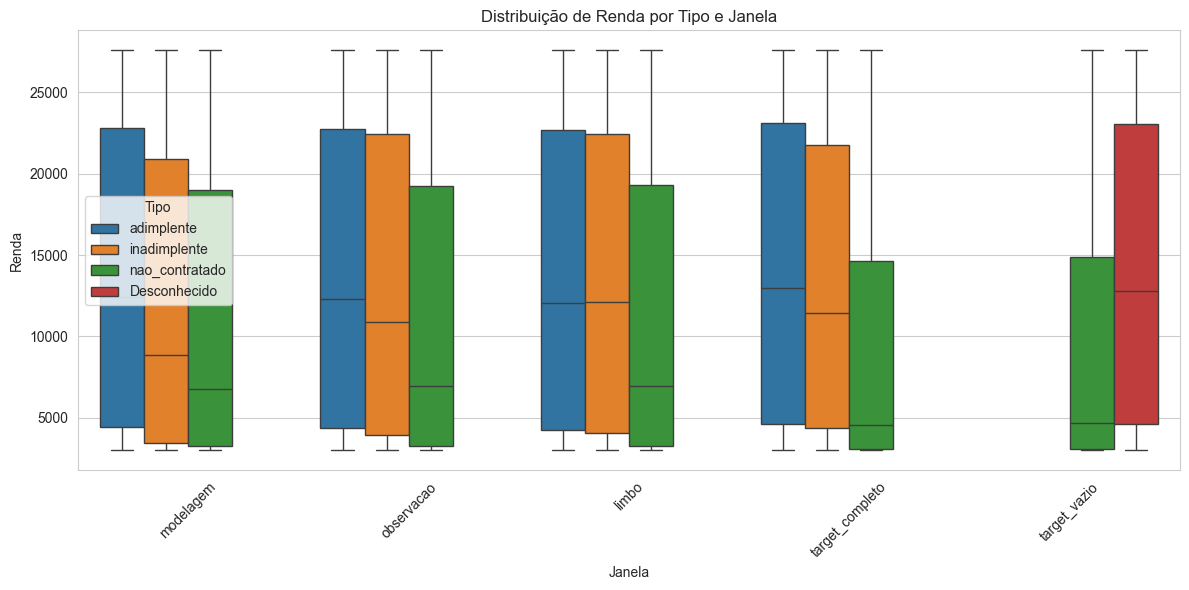

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar o estilo do gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Criar o boxplot
sns.boxplot(data=df, x='janela', y='renda', hue='tipo')

plt.title('Distribuição de Renda por Tipo e Janela')
plt.xlabel('Janela')
plt.ylabel('Renda')
plt.legend(title='Tipo')
plt.xticks(rotation=45)  # Se necessário, rotacionar os labels
plt.tight_layout()
plt.show()

In [26]:
# Para todas as idades
resultado = df[df['contratado'] == 1].groupby(['idade'])['ano_mes'].agg(['min', 'max'])
print("\n" + "---")
print('Datas de início e fim para cada idade:')
resultado[resultado['max'] != '2025-12-01']  # Idades que só aparecem a partir da janela de observação


---
Datas de início e fim para cada idade:


,min,max
idade,,
75,2022-03-01,2025-11-01
76,2022-05-01,2025-11-01
79,2022-08-01,2025-11-01
80,2022-10-01,2024-05-01
81,2022-10-01,2025-11-01
82,2022-03-01,2024-10-01
83,2022-04-01,2025-05-01
84,2023-07-01,2023-07-01
87,2025-10-01,2025-10-01


In [27]:
# Para todas as pmt = Valor da prestação
resultado = df[df['contratado'] == 1].groupby(['pmt'])['ano_mes'].agg(['min', 'max'])
print("\n" + "---")
print('Datas de início e fim para cada pmt:')
resultado[resultado['max'] != '2025-12-01'].sort_values('max')  # Pmts que só aparecem a partir da janela de observação


---
Datas de início e fim para cada pmt:


,min,max
pmt,,
8174,2022-03-01,2022-03-01
5212,2022-03-01,2022-03-01
7622,2022-03-01,2022-03-01
5135,2022-03-01,2022-03-01
5454,2022-03-01,2022-03-01
...,...,...
2274,2022-03-01,2025-11-01
2721,2022-05-01,2025-11-01
2501,2022-03-01,2025-11-01


In [28]:
# Para todas as renda = Valor da renda
resultado = df[df['contratado'] == 1].groupby(['renda'])['ano_mes'].agg(['min', 'max'])
print("\n" + "---")
print('Datas de início e fim para cada renda:')
resultado.sort_values('max')  # Rendas que só aparecem a partir da janela de observação


---
Datas de início e fim para cada renda:


,min,max
renda,,
3000,2022-03-01,2025-12-01
19005,2022-03-01,2025-12-01
19019,2022-03-01,2025-12-01
19070,2022-03-01,2025-12-01
19135,2022-03-01,2025-12-01
...,...,...
6575,2022-03-01,2025-12-01
6608,2022-03-01,2025-12-01
6641,2022-03-01,2025-12-01


# 2. Métricas de Monitoramento

1. **Estabilidade**:
   - Avalia se o perfil da população mudou.
2. **Discriminação**
   - Avalia se o modelo **ainda consegue separar corretamente os bons dos maus pagadores**;
   - Mede a capacidade do modelo em ordenar os clientes segundo o critério para o qual foi desenvolvido;
   - Uma queda no poder discriminatório pode indicar que as relações aprendidas pelo modelo durante o desenvolvimento não são mais válidas, comprometendo todas as decisões baseadas nele.
3. **Previsibilidade**
   - sadf


## 2.1. Estabilidade

In [29]:
# Selecionar as informações para análise
#filtro = ((df['tipo']  == 'adimplente') &
#          (df['score'] > 4))
df_analise_estabilidade = df_inadimplente.copy()

# Selecionar as datas para análise de PSI 
dt_esperada_inicio = '2022-03-01' # Início da Janela de Modelagem
dt_esperada_fim    = '2023-02-01' # Fim da Janela de Modelagem
dt_observacao      = '2024-12-01' # Data da análise

In [30]:
col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela_frequencia = pd.crosstab(df_analise_estabilidade['ano_mes'], df_analise_estabilidade[col], normalize='index')
tabela_frequencia.head(2)

score,5,6,7,8,9,10
ano_mes,,,,,,
2022-03-01,0.270492,0.320492,0.265574,0.105738,0.033607,0.004098
2022-04-01,0.274956,0.288967,0.268827,0.130473,0.033275,0.003503


### 2.1.1. PSI ou IEP (Índice de Estabilidade do Populacional)

In [31]:
# Esperado = a média dos valores do período entre 2022-03 e 2023-03 (Janela de Modelagem) para cada score.
esperado = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Observado = os valores de uma data específica (ex: 2024-03) para cada score.
observado = tabela_frequencia.loc[[dt_observacao]].iloc[0]
observado

# Criar DataFrame com diferença
df_psi = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,
    'PSI': (observado - esperado) * np.log(observado / esperado) # PSI = (%Obs - %Esp) * ln(%Obs / %Esp)
})

PSI = df_psi['PSI'].sum()
print(f"PSI Total: {PSI:.4f}")


PSI Total: 0.0019


In [32]:
df_psi.T

score,5,6,7,8,9,10
Esperado,0.276676,0.285747,0.269702,0.123707,0.039419,0.004749
Observado,0.268593,0.281857,0.271909,0.135481,0.038844,0.003316
PSI,0.000240,0.000053,0.000018,0.001070,0.000008,0.000514


### 2.1.2. Carta de Controle

#### 2.1.2.1. Controle do observado (dentro dos limites esperados por score)

In [33]:
# Carta de controle do observado
esperado_std = tabela_frequencia.loc[dt_esperada_inicio:dt_esperada_fim].std()

# Criar DataFrame com diferença
df_controle = pd.DataFrame({
    'Esperado': esperado,
    'Observado': observado,        
    'LS': (esperado + 2 * esperado_std), # Limite Superior = Esperado + 2 * Desvio Padrão
    'LI': (esperado - 2 * esperado_std),  # Limite Inferior = Esperado - 2 * Desvio Padrão
    'Cruzou?': (observado > (esperado + 2 * esperado_std)) | (observado < (esperado - 2 * esperado_std))
})

df_controle.T

score,5,6,7,8,9,10
Esperado,0.276676,0.285747,0.269702,0.123707,0.039419,0.004749
Observado,0.268593,0.281857,0.271909,0.135481,0.038844,0.003316
LS,0.296303,0.326155,0.301538,0.146086,0.054836,0.00847
LI,0.25705,0.245339,0.237865,0.101329,0.024001,0.001027
Cruzou?,False,False,False,False,False,False


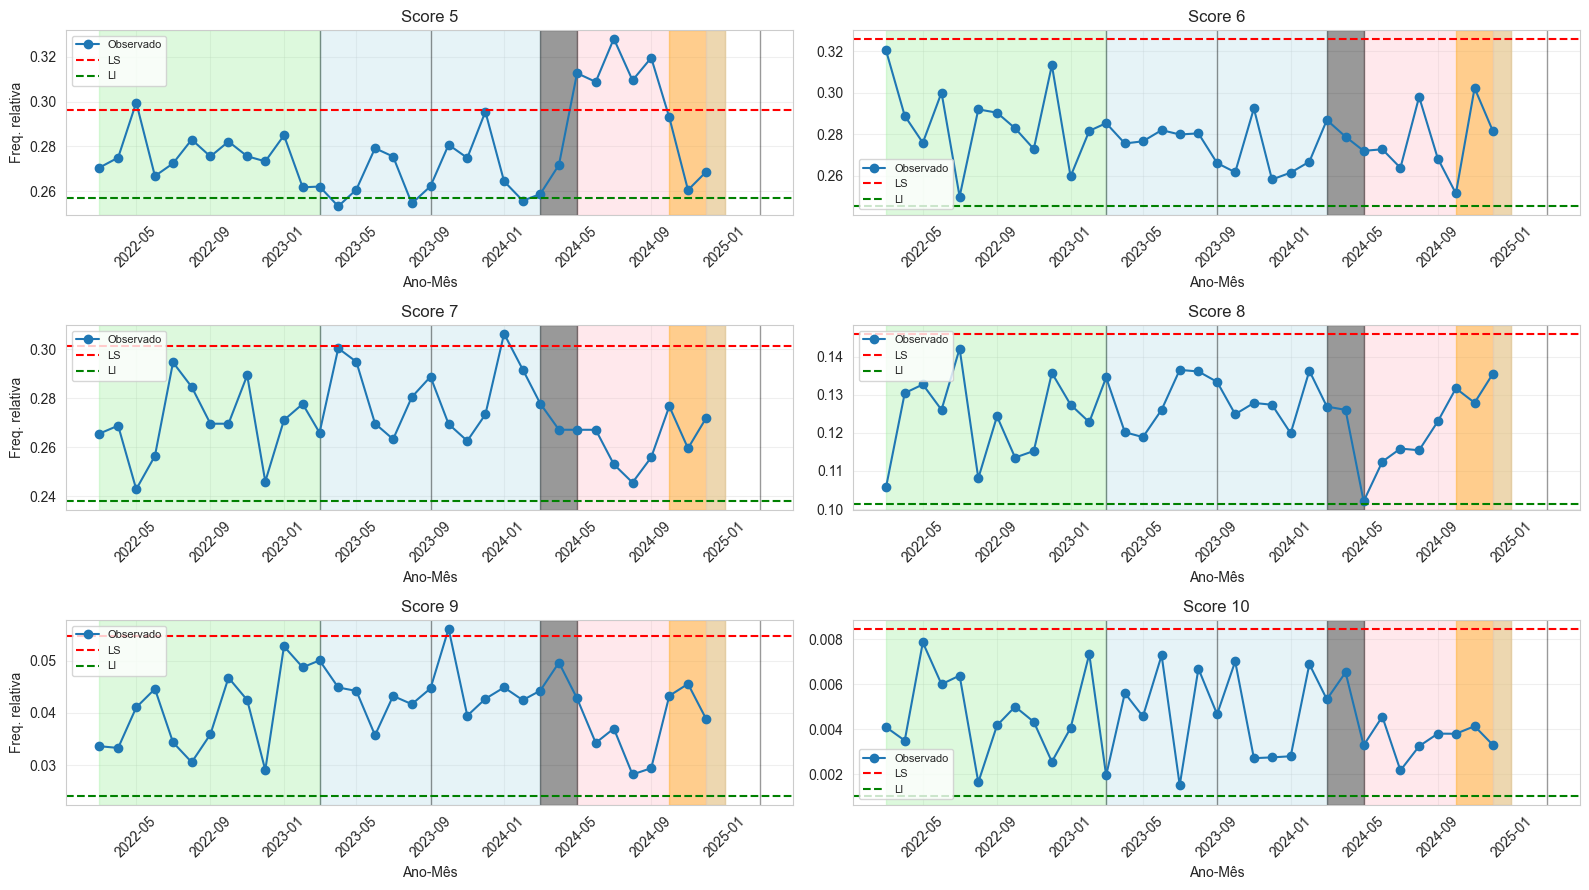

In [34]:
# Plot da frequência observada por score ao longo do tempo, comparando com LS/LI de cada score
scores = df_controle.index.to_list()
n_scores = len(scores)
n_colunas = 2
n_linhas = (n_scores + n_colunas - 1) // n_colunas  # Arredondar para cima

fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(16, 3 * n_linhas))
axes = axes.flatten()

for i, score in enumerate(scores):
    ax = axes[i]
    serie = tabela_frequencia[score]
    
    ax.plot(serie.index, serie.values, label='Observado', marker='o', linewidth=1.5)
    ax.axhline(df_controle.loc[score, 'LS'], color='red', linestyle='--', label='LS')
    ax.axhline(df_controle.loc[score, 'LI'], color='green', linestyle='--', label='LI')
    
    ax.axvspan('2022-03-01', '2023-03-01', color='lightgreen', alpha=0.3)                    # Janela de Modelagem
    ax.axvspan('2023-03-01', '2024-03-01', color='lightblue', alpha=0.3)                     # Janela de Observação
    ax.axvspan('2024-05-01', tabela_frequencia.index.max(), color='lightpink', alpha=0.3)    # Em Produção
    ax.axvspan('2024-03-01', '2024-05-01', color='black', alpha=0.4)                         # Limbo
    ax.axvspan('2023-03-01', '2023-03-01', color='black', alpha=0.4)                         # Marcador
    ax.axvspan('2023-09-01', '2023-09-01', color='black', alpha=0.4)                         # Efeito Modelo Teste
    ax.axvspan('2025-03-01', '2025-03-01', color='black', alpha=0.4)                         # Marcador
    ax.axvspan('2024-10-01', '2025-01-01', color='orange', alpha=0.4)                        # Efeito Modelo Produção
    ax.axvspan('2025-01-01', tabela_frequencia.index.max(), color='lightgray', alpha=0.4)    # Não tem target 1
    
    ax.set_title(f'Score {score}')
    ax.set_xlabel('Ano-Mês')
    if i % n_colunas == 0:
        ax.set_ylabel('Freq. relativa')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Esconder subplots vazios (se houver)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### 2.1.2.2. Controle da variação média ponderada por score

In [35]:
# Carta de Controle

# Média ponderada do score por mês (soma produto = frequência * score)
scores = tabela_frequencia.columns.to_list()
media_ponderada_score_por_mes = tabela_frequencia.dot(scores)

# Desvio padrão do período da janela de modelagem (2022-03 a 2023-02)
std_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].std() 
mean_ponderado_esperado = media_ponderada_score_por_mes.loc[dt_esperada_inicio:dt_esperada_fim].mean()

# Adicionar limites de controle
limite_superior = mean_ponderado_esperado + 2 * std_ponderado_esperado # Limite Superior
limite_inferior = mean_ponderado_esperado - 2 * std_ponderado_esperado # Limite Inferior

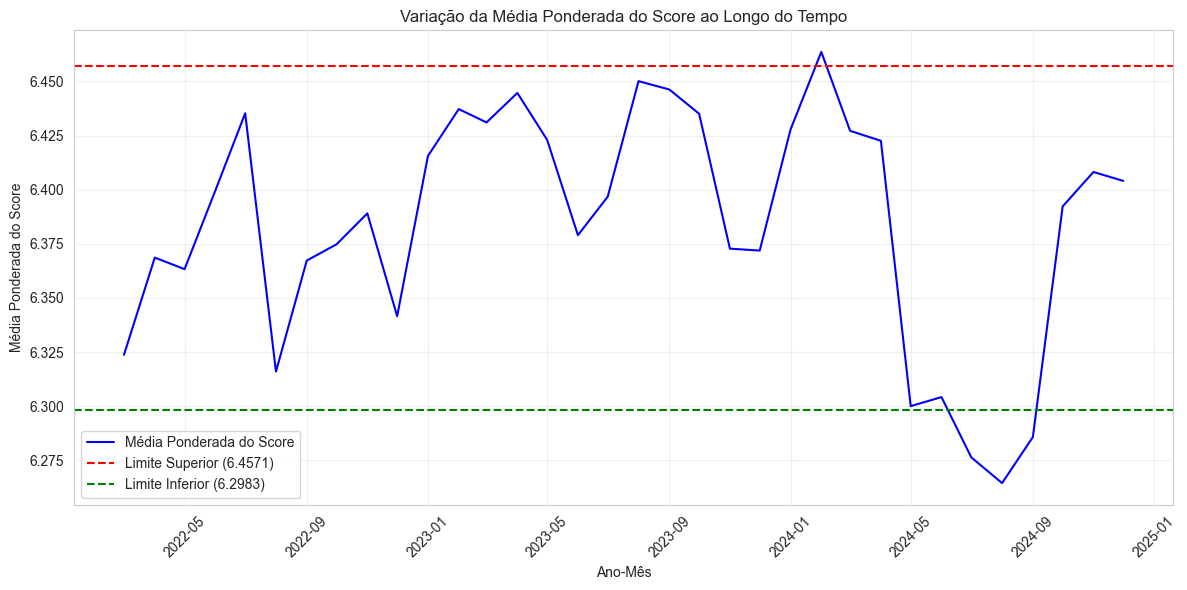

In [36]:
# Plotar a variação da média ponderada do score ao longo do tempo
plt.figure(figsize=(12, 6))
plt.plot(media_ponderada_score_por_mes.index, media_ponderada_score_por_mes.values, label='Média Ponderada do Score', color='blue')

# Adicionar linhas para os limites superior e inferior
plt.axhline(y=limite_superior, color='red', linestyle='--', label=f'Limite Superior ({limite_superior:.4f})')
plt.axhline(y=limite_inferior, color='green', linestyle='--', label=f'Limite Inferior ({limite_inferior:.4f})')

# Configurações do gráfico
plt.title('Variação da Média Ponderada do Score ao Longo do Tempo')
plt.xlabel('Ano-Mês')
plt.ylabel('Média Ponderada do Score')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2. Discriminação (Previsão)

In [37]:
# Selecionar as informações para análise
# Selecionar as informações para análise
filtro = ((df['tipo']  == 'adimplente') &
          (df['score'] > 4))
df_analise_estabilidade = df[filtro].copy()

# Selecionar as datas para análise de PSI 
dt_esperada_inicio = '2022-03-01' # Início da Janela de Modelagem
dt_esperada_fim    = '2023-02-01' # Fim da Janela de Modelagem
dt_observacao      = '2024-12-01' # Data da análise

In [38]:
# Criar tabela dinâmica com % média de contratado == 1 e % média de target == 1 (entre os contratados)
tabela_contratado = df.groupby('ano_mes')['contratado'].mean().reset_index()
tabela_contratado.columns = ['ano_mes', '%_media_contratado']

tabela_target = df[df['contratado'] == 1].groupby('ano_mes')['target'].mean().reset_index()
tabela_target.columns = ['ano_mes', '%_media_inadimplente']

# Adicionar % média de FPD por ano_mes
tabela_fpd = df.groupby('ano_mes')['FPD'].mean().reset_index()
tabela_fpd.columns = ['ano_mes', '%_media_fpd']

# Mesclar as tabelas
tabela_dinamica = pd.merge(tabela_contratado, tabela_target, on='ano_mes', how='left')
tabela_dinamica = pd.merge(tabela_dinamica, tabela_fpd, on='ano_mes', how='left')

# Exibir a tabela
tabela_dinamica.tail(12)

,ano_mes,%_media_contratado,%_media_inadimplente,%_media_fpd
34,2025-01-01,0.858789,NaN,0.049566
35,2025-02-01,0.856024,NaN,0.047309
36,2025-03-01,0.859629,NaN,0.049589
37,2025-04-01,0.760629,NaN,0.029159
38,2025-05-01,0.762728,NaN,0.034479
39,2025-06-01,0.763065,NaN,0.032144
40,2025-07-01,0.756815,NaN,0.029212
41,2025-08-01,0.762028,NaN,0.028509
42,2025-09-01,0.763114,NaN,0.028642
43,2025-10-01,0.760003,NaN,0.030226


In [39]:
print('Previsão de Aprovação e Inadimplência):')
print('  % Média de Aprovação     : {:.2f}% (até 2025-12)'.format(tabela_dinamica['%_media_contratado'].mean() * 100))
# Calcular a média de % de inadimplência entre os contratados apenas até 2025-01 (antes do período sem target 1)
media_inadimplencia = tabela_dinamica[tabela_dinamica['ano_mes'] < '2025-01-01']['%_media_inadimplente'].mean()
print('  % Média de Inadimplência : {:.2f}% (até 2024-12)'.format(media_inadimplencia * 100))

Previsão de Aprovação e Inadimplência):
  % Média de Aprovação     : 77.21% (até 2025-12)
  % Média de Inadimplência : 13.02% (até 2024-12)


**Métricas**
1. KS: 
   - Se propõe a ordenar;
   - Mede a maior distanância entre clientes bons e maus;
2. ROC: 
   - 
3. Gini: 
   - 

### 2.2.1. KS

In [40]:
# Preparar os dados para as funções ks
y_target = df[(df['ano_mes'] >= '2022-03-01') & 
              (df['ano_mes'] <= '2023-02-01') & 
              (df['score'] > 4)]['target'].values     # Valores reais (0 ou 1) # Apenas na janela de modelagem
y_score = df[(df['ano_mes'] >= '2022-03-01') & 
              (df['ano_mes'] <= '2023-02-01') & 
              (df['score'] > 4)]['score'].values        # Scores do modelo

# Calcular KS
ks, p_value = calcular_ks(y_target, y_score)
print(f"KS Esperado (Janela de Modelagem): {ks:.4f}")

# Plotar a curva KS (Isso aqui está estranho)
# plot_ks(y_target, y_score, titulo="KS - Modelo de Crédito")

KS Esperado (Janela de Modelagem): 0.2554


#### 2.2.1.2. KS Passo a passo - Didático, como o da aula do Danilo

- É a tabela de frequência acumulada por ano_mes ao longo dos scores

In [41]:
# Selecionar as informações para análise
filtro = ((df['ano_mes'] >= '2022-03-01') & 
          (df['ano_mes'] <= '2023-02-01') & 
          (df['score'] > 4) &
          (df['contratado']  == 1) &
          (df['target'] == 0))
df_bons_pagadores = df[filtro].copy()

# Selecionar as datas para análise de PSI 
#dt_esperada_inicio = '2022-03-01' # Início da Janela de Modelagem
#dt_esperada_fim    = '2023-02-01' # Fim da Janela de Modelagem
#dt_observacao      = '2024-12-01' # Data da análise

col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela = pd.crosstab(df_bons_pagadores['ano_mes'], 
                     df_bons_pagadores[col], 
                     normalize='index')

# Calcular distribuição acumulada (cumsum) ao longo dos scores
tabela_acumulada_bons_pagadores = tabela.cumsum(axis=1)

print("Frequência acumulada por score:")
tabela_acumulada_bons_pagadores.T

Frequência acumulada por score:


ano_mes,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01
score,,,,,,,,,,,,
5,0.122325,0.123748,0.124736,0.128086,0.121849,0.125302,0.122160,0.121388,0.125260,0.118768,0.126313,0.119286
6,0.302357,0.306928,0.307537,0.318178,0.301964,0.309879,0.293703,0.304799,0.311943,0.306614,0.311875,0.301363
7,0.591473,0.588362,0.584016,0.600781,0.582079,0.592914,0.583047,0.586931,0.589882,0.591741,0.596101,0.581594
8,0.821301,0.825097,0.819732,0.828111,0.824223,0.825761,0.825606,0.821737,0.822569,0.829109,0.828305,0.824737
9,0.964277,0.963745,0.965651,0.966919,0.965876,0.965236,0.964870,0.961392,0.965414,0.964412,0.967392,0.965241
10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
# Selecionar as informações para análise
filtro = ((df['ano_mes'] >= '2022-03-01') & 
          (df['ano_mes'] <= '2023-02-01') & 
          (df['score'] > 4) &
          (df['contratado']  == 1) &
          (df['target'] == 1))
df_maus_pagadores = df[filtro].copy()

col = 'score'

# Tabela dinâmica de frequência relativa por ano_mes e score
tabela = pd.crosstab(df_maus_pagadores['ano_mes'], 
                     df_maus_pagadores[col], 
                     normalize='index')

# Calcular distribuição acumulada (cumsum) ao longo dos scores
tabela_acumulada_maus_pagadores = tabela.cumsum(axis=1)

print("Frequência acumulada por score:")
tabela_acumulada_maus_pagadores.T

Frequência acumulada por score:


ano_mes,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01
score,,,,,,,,,,,,
5,0.270492,0.274956,0.299563,0.266724,0.272364,0.283003,0.275459,0.282137,0.275563,0.273271,0.284903,0.261682
6,0.590984,0.563923,0.575546,0.566895,0.522364,0.575083,0.565943,0.565109,0.548527,0.586678,0.544643,0.543391
7,0.856557,0.832750,0.818341,0.823328,0.817093,0.859736,0.835559,0.834725,0.837955,0.832622,0.815747,0.821095
8,0.962295,0.963222,0.951092,0.949400,0.959265,0.967822,0.959933,0.948247,0.953206,0.968403,0.943182,0.943925
9,0.995902,0.996497,0.992140,0.993997,0.993610,0.998350,0.995826,0.994992,0.995667,0.997438,0.995942,0.992657
10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
# Fazer uma tabela de diferença entre a frequência acumulada dos maus pagadores e dos bons pagadores
tabela_diferenca_ks = abs(tabela_acumulada_maus_pagadores - tabela_acumulada_bons_pagadores)
tabela_diferenca_ks.head()

score,5,6,7,8,9,10
ano_mes,,,,,,
2022-03-01,0.148167,0.288627,0.265084,0.140994,0.031625,1.110223e-16
2022-04-01,0.151208,0.256995,0.244388,0.138125,0.032753,2.220446e-16
2022-05-01,0.174827,0.268009,0.234325,0.131360,0.026489,1.110223e-16
2022-06-01,0.138638,0.248717,0.222546,0.121289,0.027078,0.000000e+00
2022-07-01,0.150515,0.220400,0.235014,0.135043,0.027735,0.000000e+00


In [44]:
# O KS é o valor máximo da tabela de diferenca por mes_ano
tabela_ks = tabela_diferenca_ks.max(axis=1).reset_index()
tabela_ks.columns = ['ano_mes', 'KS']

tabela_ks.head()

,ano_mes,KS
0,2022-03-01,0.288627
1,2022-04-01,0.256995
2,2022-05-01,0.268009
3,2022-06-01,0.248717
4,2022-07-01,0.235014


In [45]:
# Apenas no período da janela de modelagem (2022-03 a 2023-02)
tabela_ks_filtrada = tabela_ks[(tabela_ks['ano_mes'] >= '2022-03-01') & (tabela_ks['ano_mes'] <= '2023-02-01')]
ks_total = tabela_ks_filtrada['KS'].mean()
print(f"KS Total: {ks_total:.4f}")

KS Total: 0.2583


## 2.3. Previsibilidade

**Métricas**:
1. Observado x Esperado

### 2.3.1. Observado x Esperado (GH)

### 2.3.2. FPD (First Payment Default)

In [46]:
def calcular_fpd(df, col_contrato='contratado', col_fpd='FPD', col_score='score'):
    """
    Calcula taxa de FPD por faixa de score
    
    Parameters:
    -----------
    df : DataFrame
        Dados com contratos e indicador FPD
    col_contrato : str
        Coluna que indica se o contrato foi efetivado
    col_fpd : str
        Coluna com indicador FPD (0/1 ou NaN para não contratados)
    col_score : str
        Coluna com score do modelo
    """
    
    # Filtrar apenas contratados
    contratados = df[df[col_contrato] == 1].copy()
    
    # Tratar FPD (assumindo que NaN significa não FPD)
    contratados['fpd_flag'] = contratados[col_fpd].fillna(0)
    
    # Calcular taxa de FPD por score
    fpd_por_score = contratados.groupby(col_score).agg({
        'fpd_flag': ['count', 'sum', 'mean']
    }).round(4)
    
    fpd_por_score.columns = ['total_contratos', 'total_fpd', 'taxa_fpd']
    fpd_por_score = fpd_por_score.reset_index()
    
    return fpd_por_score

In [47]:
# Uso:
fpd_analysis = calcular_fpd(df)
print("Taxa de FPD por Score:")
print(fpd_analysis)

Taxa de FPD por Score:
   score  total_contratos  total_fpd  taxa_fpd
0      1             3319      384.0    0.1157
1      2             6548      596.0    0.0910
2      3            15813     1262.0    0.0798
3      4            26767     1609.0    0.0601
4      5            89679     4600.0    0.0513
5      6           119212     4630.0    0.0388
6      7           170617     4965.0    0.0291
7      8           132195     2580.0    0.0195
8      9            74340      953.0    0.0128
9     10            16961      149.0    0.0088


### 2.3.3. WOE (Weight of Evidence) e IV (Information Value)

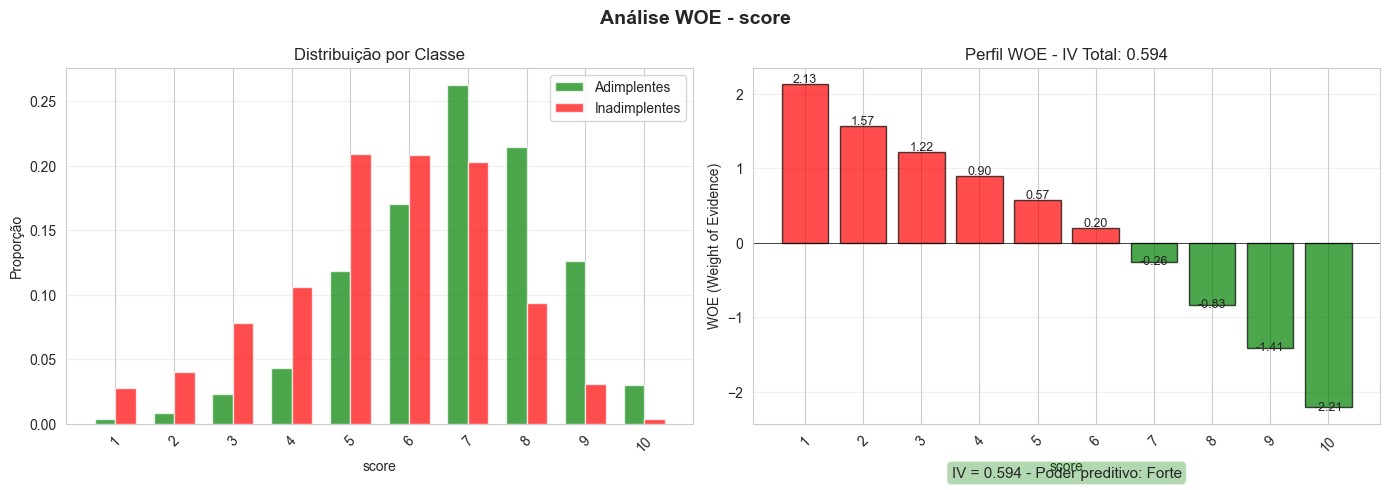


IV do Score: 0.594


In [48]:
def calcular_woe_iv(df, var, target='target'):
    """
    Calcula WOE (Weight of Evidence) e IV (Information Value) para uma variável
    
    Parameters:
    -----------
    df : DataFrame
        Dados com a variável e target
    var : str
        Nome da variável (categórica ou binned)
    target : str
        Nome da coluna target (0 = adimplente, 1 = inadimplente)
    
    Returns:
    --------
    DataFrame com estatísticas e WOE/IV
    """
    
    # Tabela de contingência
    tabela = pd.crosstab(df[var], df[target], margins=True, margins_name='Total')
    
    # Renomear colunas
    tabela.columns = ['Adimplentes', 'Inadimplentes', 'Total']
    
    # Calcular percentuais
    total_adimplentes = tabela.loc['Total', 'Adimplentes']
    total_inadimplentes = tabela.loc['Total', 'Inadimplentes']
    total_geral = tabela.loc['Total', 'Total']
    
    # DataFrame para resultados (excluir linha Total)
    resultado = tabela.drop('Total').copy()
    
    # Calcular percentuais
    resultado['%_Adimplentes'] = resultado['Adimplentes'] / total_adimplentes
    resultado['%_Inadimplentes'] = resultado['Inadimplentes'] / total_inadimplentes
    
    # Calcular WOE (com suavização para evitar log(0))
    resultado['WOE'] = np.log(
        (resultado['%_Inadimplentes'] + 1e-10) / 
        (resultado['%_Adimplentes'] + 1e-10)
    )
    
    # Calcular contribuição para IV
    resultado['IV_contrib'] = (resultado['%_Inadimplentes'] - resultado['%_Adimplentes']) * resultado['WOE']
    
    # IV total
    iv_total = resultado['IV_contrib'].sum()
    
    # Adicionar totais
    resultado.loc['Total'] = [
        total_adimplentes, total_inadimplentes, total_geral,
        1.0, 1.0, np.nan, iv_total
    ]
    
    return resultado, iv_total

def plot_woe_analysis(df, var, target='target', titulo=None):
    """
    Visualiza análise WOE para uma variável
    """
    # Calcular WOE
    woe_df, iv_total = calcular_woe_iv(df, var, target)
    
    # Remover linha Total para plot
    woe_plot = woe_df.drop('Total').copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Distribuição das classes
    ax1 = axes[0]
    x = range(len(woe_plot.index))
    width = 0.35
    
    ax1.bar([i - width/2 for i in x], woe_plot['%_Adimplentes'], width, 
            label='Adimplentes', color='green', alpha=0.7)
    ax1.bar([i + width/2 for i in x], woe_plot['%_Inadimplentes'], width, 
            label='Inadimplentes', color='red', alpha=0.7)
    
    ax1.set_xlabel(var)
    ax1.set_ylabel('Proporção')
    ax1.set_title('Distribuição por Classe')
    ax1.set_xticks(x)
    ax1.set_xticklabels(woe_plot.index, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Gráfico 2: WOE
    ax2 = axes[1]
    cores = ['red' if w > 0 else 'green' for w in woe_plot['WOE']]
    ax2.bar(x, woe_plot['WOE'], color=cores, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Adicionar valores
    for i, (idx, row) in enumerate(woe_plot.iterrows()):
        ax2.text(i, row['WOE'] + (0.02 if row['WOE'] > 0 else -0.04), 
                f'{row["WOE"]:.2f}', ha='center', fontsize=9)
    
    ax2.set_xlabel(var)
    ax2.set_ylabel('WOE (Weight of Evidence)')
    ax2.set_title(f'Perfil WOE - IV Total: {iv_total:.3f}')
    ax2.set_xticks(x)
    ax2.set_xticklabels(woe_plot.index, rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Interpretação do IV
    if iv_total < 0.02:
        cor_iv = 'red'
        interprete = 'Não preditivo'
    elif iv_total < 0.1:
        cor_iv = 'orange'
        interprete = 'Fraco'
    elif iv_total < 0.3:
        cor_iv = 'blue'
        interprete = 'Médio'
    else:
        cor_iv = 'green'
        interprete = 'Forte'
    
    ax2.text(0.5, -0.15, f'IV = {iv_total:.3f} - Poder preditivo: {interprete}', 
            transform=ax2.transAxes, ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor=cor_iv, alpha=0.3))
    
    titulo_geral = titulo if titulo else f'Análise WOE - {var}'
    plt.suptitle(titulo_geral, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return woe_df, iv_total

# Uso:
woe_score, iv_score = plot_woe_analysis(df, 'score')
print(f"\nIV do Score: {iv_score:.3f}")